Cell 1. Import packages

In [1]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import warnings

Cell 2. File paths

In [2]:
file_dict = {
    "BE_2007": "/content/BE_2007_prepared_with_eqincome_agegroup.csv",
    "BE_2009": "/content/BE_2009_prepared_with_eqincome_agegroup.csv",
    "ES_2007": "/content/ES_2007_prepared_with_eqincome_agegroup.csv",
    "ES_2009": "/content/ES_2009_prepared_with_eqincome_agegroup.csv",
    "FI_2007": "/content/FI_2007_prepared_with_eqincome_agegroup.csv",
    "FI_2009": "/content/FI_2009_prepared_with_eqincome_agegroup.csv",
    "RO_2007": "/content/RO_2007_prepared_with_eqincome_agegroup.csv",
    "RO_2009": "/content/RO_2009_prepared_with_eqincome_agegroup.csv",
}

Cell 3. Helper functions and reference categories

In [3]:
# -----------------------------
# Reference groups
# -----------------------------

# Keep age reference consistent with Lorenz part:
# age 15-24, 55-64, 65+ are compared with 25-54.
AGE_REF = "25-54"

# Education reference:
# Primary education is used as the reference if available.
EDU_REF = "Primary education"

# Health reference:
# Good health is used as the reference if available.
HEALTH_REF = "Good health"

# Region references chosen to align with the Lorenz interpretation where possible.
# If a reference is absent in a dataset, the code will fall back to alphabetical first category.
REGION_REF_BY_COUNTRY = {
    "BE": "BE10",  # Brussels-Capital Region
    "ES": "ES11",  # Galicia
    "FI": "FI19",  # Western Finland
    "RO": "RO21",  # North-East
}

# Country names used in citizenship reference.
COUNTRY_CODE_BY_DATASET_PREFIX = {
    "BE": "BE",
    "ES": "ES",
    "FI": "FI",
    "RO": "RO",
}


# -----------------------------
# Label mappings
# -----------------------------

SEX_MAP = {
    1: "Male",
    2: "Female",
    "1": "Male",
    "2": "Female",
}

# PE040 is treated as categorical.
# These labels follow the usual ISCED-style ordering.
# If your codebook uses slightly different wording, only the labels need changing.
EDUCATION_MAP = {
    0: "Pre-primary education",
    1: "Primary education",
    2: "Lower secondary education",
    3: "Upper secondary education",
    4: "Post-secondary non-tertiary education",
    5: "Tertiary first stage",
    6: "Tertiary second stage",
    "0": "Pre-primary education",
    "1": "Primary education",
    "2": "Lower secondary education",
    "3": "Upper secondary education",
    "4": "Post-secondary non-tertiary education",
    "5": "Tertiary first stage",
    "6": "Tertiary second stage",
}

# PH010 is treated as categorical.
# Usual EU-SILC coding:
# 1 = very good, 2 = good, 3 = fair, 4 = bad, 5 = very bad.
HEALTH_MAP = {
    1: "Very good health",
    2: "Good health",
    3: "Fair health",
    4: "Bad health",
    5: "Very bad health",
    "1": "Very good health",
    "2": "Good health",
    "3": "Fair health",
    "4": "Bad health",
    "5": "Very bad health",
}


def clean_code_value(x):
    """
    Convert values like 1.0 to 1 where possible.
    Keep strings like 'BE10' unchanged.
    """
    if pd.isna(x):
        return np.nan

    # Try numeric integer conversion
    try:
        xf = float(x)
        if xf.is_integer():
            return int(xf)
    except Exception:
        pass

    return str(x)


def map_with_fallback(series, mapping, prefix="Code"):
    """
    Map known codes to readable labels.
    Unknown non-missing codes become 'Code: value'.
    """
    cleaned = series.apply(clean_code_value)

    def mapper(x):
        if pd.isna(x):
            return np.nan
        if x in mapping:
            return mapping[x]
        if str(x) in mapping:
            return mapping[str(x)]
        return f"{prefix}: {x}"

    return cleaned.apply(mapper)


def normalize_age_group(x):
    """
    Convert different possible age-group labels to one common format.
    """
    if pd.isna(x):
        return np.nan

    s = str(x).strip()
    s = s.replace("–", "-").replace("_", "-").replace(" ", "")
    s = s.lower()

    if s in ["15-24", "15to24", "15/24"]:
        return "15-24"
    elif s in ["25-54", "25to54", "25/54"]:
        return "25-54"
    elif s in ["55-64", "55to64", "55/64"]:
        return "55-64"
    elif s in ["65+", "65plus", "65-plus", "65_and_above"]:
        return "65+"
    else:
        return str(x)


def set_reference_category(series, reference, variable_name="variable"):
    """
    Put the reference category first, so get_dummies(drop_first=True)
    uses it as the omitted category.
    """
    values = pd.Series(series.dropna().unique()).astype(str).tolist()

    if reference in values:
        categories = [reference] + sorted([v for v in values if v != reference])
    else:
        categories = sorted(values)
        print(f"Warning: reference '{reference}' not found for {variable_name}.")
        print(f"Using '{categories[0]}' as reference instead.")

    return pd.Categorical(series.astype(str), categories=categories)


def country_from_dataset(dataset_name):
    return dataset_name.split("_")[0]


def year_from_dataset(dataset_name):
    return dataset_name.split("_")[1]

Cell 4. Check category counts before modelling

In [4]:
category_count_rows = []

for dataset_name, file_path in file_dict.items():
    df_tmp = pd.read_csv(file_path)
    country = country_from_dataset(dataset_name)

    # Clean labels for inspection
    df_tmp["Sex_label"] = map_with_fallback(df_tmp["PB150"], SEX_MAP, prefix="Sex code")
    df_tmp["Education_label"] = map_with_fallback(df_tmp["PE040"], EDUCATION_MAP, prefix="Education code")
    df_tmp["Health_label"] = map_with_fallback(df_tmp["PH010"], HEALTH_MAP, prefix="Health code")
    df_tmp["Age_group_label"] = df_tmp["age_group"].apply(normalize_age_group)

    # Citizenship readable labels
    national_code = COUNTRY_CODE_BY_DATASET_PREFIX[country]

    def citizenship_label(x):
        if pd.isna(x):
            return np.nan
        x = str(x)
        if x == national_code:
            return "National citizenship"
        elif x == "EU":
            return "EU citizenship"
        elif x == "Other":
            return "Other citizenship"
        else:
            return f"Citizenship code: {x}"

    df_tmp["Citizenship_label"] = df_tmp["PB220A"].apply(citizenship_label)
    df_tmp["Region_label"] = df_tmp["DB040"].astype(str)

    check_vars = {
        "Sex": "Sex_label",
        "Citizenship": "Citizenship_label",
        "Age group": "Age_group_label",
        "Education": "Education_label",
        "Health": "Health_label",
        "Region": "Region_label",
    }

    for var_name, col in check_vars.items():
        counts = df_tmp[col].value_counts(dropna=False)
        percents = df_tmp[col].value_counts(normalize=True, dropna=False) * 100

        for category in counts.index:
            category_count_rows.append({
                "Dataset": dataset_name,
                "Variable": var_name,
                "Category": category,
                "n": counts.loc[category],
                "Percent": percents.loc[category],
            })

category_counts = pd.DataFrame(category_count_rows)
category_counts["Percent"] = category_counts["Percent"].round(2)

# Compact display: citizenship counts are most important to inspect
print("Citizenship counts:")
display(category_counts[category_counts["Variable"] == "Citizenship"])

print("Age group counts:")
display(category_counts[category_counts["Variable"] == "Age group"])

print("Education counts:")
display(category_counts[category_counts["Variable"] == "Education"])

print("Health counts:")
display(category_counts[category_counts["Variable"] == "Health"])

Citizenship counts:


,Dataset,Variable,Category,n,Percent
2,BE_2007,Citizenship,National citizenship,10687,89.25
3,BE_2007,Citizenship,EU citizenship,700,5.85
4,BE_2007,Citizenship,Other citizenship,398,3.32
5,BE_2007,Citizenship,NaN,189,1.58
37,BE_2009,Citizenship,National citizenship,10187,88.13
38,BE_2009,Citizenship,EU citizenship,667,5.77
39,BE_2009,Citizenship,Other citizenship,522,4.52
40,BE_2009,Citizenship,NaN,183,1.58
72,ES_2007,Citizenship,National citizenship,25430,89.40
73,ES_2007,Citizenship,Other citizenship,1836,6.45


Age group counts:


,Dataset,Variable,Category,n,Percent
6,BE_2007,Age group,25-54,6147,51.34
7,BE_2007,Age group,65+,2593,21.66
8,BE_2007,Age group,55-64,1823,15.22
9,BE_2007,Age group,15-24,1411,11.78
41,BE_2009,Age group,25-54,5830,50.44
42,BE_2009,Age group,65+,2495,21.58
43,BE_2009,Age group,55-64,1804,15.61
44,BE_2009,Age group,15-24,1430,12.37
76,ES_2007,Age group,25-54,15626,54.93
77,ES_2007,Age group,65+,6149,21.62


Education counts:


,Dataset,Variable,Category,n,Percent
10,BE_2007,Education,Upper secondary education,3649,30.47
11,BE_2007,Education,Tertiary first stage,3414,28.51
12,BE_2007,Education,Lower secondary education,1634,13.65
13,BE_2007,Education,Primary education,1447,12.08
14,BE_2007,Education,NaN,1435,11.98
15,BE_2007,Education,Post-secondary non-tertiary education,304,2.54
16,BE_2007,Education,Tertiary second stage,80,0.67
17,BE_2007,Education,Pre-primary education,11,0.09
45,BE_2009,Education,Upper secondary education,3276,28.34
46,BE_2009,Education,Tertiary first stage,3167,27.40


Health counts:


,Dataset,Variable,Category,n,Percent
18,BE_2007,Health,Good health,5575,46.56
19,BE_2007,Health,Very good health,3307,27.62
20,BE_2007,Health,Fair health,2042,17.05
21,BE_2007,Health,Bad health,795,6.64
22,BE_2007,Health,Very bad health,180,1.50
23,BE_2007,Health,NaN,75,0.63
53,BE_2009,Health,Good health,5208,45.06
54,BE_2009,Health,Very good health,3267,28.26
55,BE_2009,Health,Fair health,2023,17.50
56,BE_2009,Health,Bad health,790,6.83


Cell 5. Quantile regression function

In [5]:
def prepare_extended_circumstance_data(file_path, dataset_name):
    """
    Prepare one dataset for the extended circumstance quantile model.

    Outcome:
        log(eq_income)

    Predictors:
        Sex
        Citizenship
        Region
        Age group, reference = 25-54
        Education, categorical, reference = Primary education if available
        Health, categorical, reference = Good health if available
    """

    df = pd.read_csv(file_path)
    country = country_from_dataset(dataset_name)

    # Rename raw variables to readable names
    df = df.rename(columns={
        "eq_income": "Equivalised income",
        "PB150": "Sex_raw",
        "PB220A": "Citizenship_raw",
        "DB040": "Region_raw",
        "age_group": "Age group_raw",
        "PE040": "Education_raw",
        "PH010": "Health_raw",
        "PB040": "Weight_raw",
    })

    required_raw_vars = [
        "Equivalised income",
        "Sex_raw",
        "Citizenship_raw",
        "Region_raw",
        "Age group_raw",
        "Education_raw",
        "Health_raw",
    ]

    raw_n = len(df)

    df_model = df[required_raw_vars].copy()

    # Keep only positive equivalised income because we use log income
    df_model = df_model[df_model["Equivalised income"] > 0].copy()

    # Drop missing only in required variables
    df_model = df_model.dropna(subset=required_raw_vars).copy()

    clean_n = len(df_model)

    # Outcome
    df_model["Log equivalised income"] = np.log(df_model["Equivalised income"])

    # Readable labels
    df_model["Sex"] = map_with_fallback(df_model["Sex_raw"], SEX_MAP, prefix="Sex code")

    national_code = COUNTRY_CODE_BY_DATASET_PREFIX[country]

    def citizenship_label(x):
        if pd.isna(x):
            return np.nan
        x = str(x)
        if x == national_code:
            return "National citizenship"
        elif x == "EU":
            return "EU citizenship"
        elif x == "Other":
            return "Other citizenship"
        else:
            return f"Citizenship code: {x}"

    df_model["Citizenship"] = df_model["Citizenship_raw"].apply(citizenship_label)
    df_model["Region"] = df_model["Region_raw"].astype(str)
    df_model["Age group"] = df_model["Age group_raw"].apply(normalize_age_group)
    df_model["Highest education attained"] = map_with_fallback(
        df_model["Education_raw"],
        EDUCATION_MAP,
        prefix="Education code"
    )
    df_model["Self-perceived health"] = map_with_fallback(
        df_model["Health_raw"],
        HEALTH_MAP,
        prefix="Health code"
    )

    # Set reference categories
    df_model["Sex"] = pd.Categorical(
        df_model["Sex"],
        categories=["Male", "Female"]
    )

    df_model["Citizenship"] = pd.Categorical(
        df_model["Citizenship"],
        categories=[
            "National citizenship",
            "EU citizenship",
            "Other citizenship"
        ]
    )

    df_model["Age group"] = pd.Categorical(
        df_model["Age group"],
        categories=[
            "25-54",
            "15-24",
            "55-64",
            "65+"
        ]
    )

    # Region reference by country
    region_ref = REGION_REF_BY_COUNTRY.get(country, None)
    if region_ref is not None:
        df_model["Region"] = set_reference_category(
            df_model["Region"],
            region_ref,
            variable_name=f"{dataset_name} Region"
        )
    else:
        df_model["Region"] = pd.Categorical(df_model["Region"])

    # Education and health references
    df_model["Highest education attained"] = set_reference_category(
        df_model["Highest education attained"],
        EDU_REF,
        variable_name=f"{dataset_name} Education"
    )

    df_model["Self-perceived health"] = set_reference_category(
        df_model["Self-perceived health"],
        HEALTH_REF,
        variable_name=f"{dataset_name} Health"
    )

    # Define y
    y = df_model["Log equivalised income"].astype(float)

    # Define X
    X = df_model[
        [
            "Sex",
            "Citizenship",
            "Region",
            "Age group",
            "Highest education attained",
            "Self-perceived health"
        ]
    ].copy()

    # Dummy encode all categorical predictors
    X = pd.get_dummies(
        X,
        columns=[
            "Sex",
            "Citizenship",
            "Region",
            "Age group",
            "Highest education attained",
            "Self-perceived health"
        ],
        drop_first=True
    )

    # Clean dummy names
    X.columns = (
        X.columns
        .str.replace("Sex_", "Sex: ", regex=False)
        .str.replace("Citizenship_", "Citizenship: ", regex=False)
        .str.replace("Region_", "Region: ", regex=False)
        .str.replace("Age group_", "Age group: ", regex=False)
        .str.replace("Highest education attained_", "Education: ", regex=False)
        .str.replace("Self-perceived health_", "Health: ", regex=False)
    )

    # Remove no-variation columns
    X = X.loc[:, X.nunique(dropna=False) > 1]

    X = X.astype(float)
    X = sm.add_constant(X, has_constant="add")

    return df_model, X, y, raw_n, clean_n


def run_quantile_one_dataset(file_path, dataset_name, quantiles=[0.25, 0.50, 0.75]):
    df_model, X, y, raw_n, clean_n = prepare_extended_circumstance_data(file_path, dataset_name)

    rows = []

    for q in quantiles:
        print(f"Running {dataset_name}, q = {q}")

        model = sm.QuantReg(y, X)

        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            res = model.fit(q=q, max_iter=5000)

        conf = res.conf_int()

        for var in res.params.index:
            rows.append({
                "Dataset": dataset_name,
                "Quantile": q,
                "Variable": var,
                "Coefficient": res.params[var],
                "P-value": res.pvalues[var],
                "Lower CI": conf.loc[var, 0],
                "Upper CI": conf.loc[var, 1],
                "Raw n": raw_n,
                "Model n": clean_n
            })

    result = pd.DataFrame(rows)
    return result

Cell 6. Run all datasets

In [6]:
all_results = []

for dataset_name, file_path in file_dict.items():
    print("\n" + "=" * 70)
    print(f"Running dataset: {dataset_name}")
    print("=" * 70)

    result = run_quantile_one_dataset(file_path, dataset_name)
    all_results.append(result)

quantile_results = pd.concat(all_results, ignore_index=True)

quantile_results.head()


Running dataset: BE_2007
Running BE_2007, q = 0.25
Running BE_2007, q = 0.5
Running BE_2007, q = 0.75

Running dataset: BE_2009
Running BE_2009, q = 0.25
Running BE_2009, q = 0.5
Running BE_2009, q = 0.75

Running dataset: ES_2007
Running ES_2007, q = 0.25
Running ES_2007, q = 0.5
Running ES_2007, q = 0.75

Running dataset: ES_2009
Running ES_2009, q = 0.25
Running ES_2009, q = 0.5
Running ES_2009, q = 0.75

Running dataset: FI_2007
Running FI_2007, q = 0.25
Running FI_2007, q = 0.5
Running FI_2007, q = 0.75

Running dataset: FI_2009
Using 'Lower secondary education' as reference instead.
Running FI_2009, q = 0.25
Running FI_2009, q = 0.5
Running FI_2009, q = 0.75

Running dataset: RO_2007
Using 'RO01' as reference instead.
Running RO_2007, q = 0.25
Running RO_2007, q = 0.5
Running RO_2007, q = 0.75

Running dataset: RO_2009
Running RO_2009, q = 0.25
Running RO_2009, q = 0.5
Running RO_2009, q = 0.75


,Dataset,Quantile,Variable,Coefficient,P-value,Lower CI,Upper CI,Raw n,Model n
0,BE_2007,0.25,const,9.458864,0.000000e+00,9.353826,9.563902,11974,9821
1,BE_2007,0.25,Sex: Female,-0.144924,1.028531e-10,-0.188834,-0.101015,11974,9821
2,BE_2007,0.25,Citizenship: EU citizenship,-0.135661,7.200695e-03,-0.234592,-0.036730,11974,9821
3,BE_2007,0.25,Citizenship: Other citizenship,-0.307486,3.710514e-05,-0.453543,-0.161428,11974,9821
4,BE_2007,0.25,Region: BE21,0.013226,7.713340e-01,-0.075976,0.102427,11974,9821


Cell 7. Create compact outputs for review

In [7]:
qr = quantile_results.copy()
qr["Quantile"] = qr["Quantile"].astype(float)

# -----------------------------
# Significance stars
# -----------------------------

def significance_stars(p):
    if pd.isna(p):
        return ""
    elif p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    elif p < 0.1:
        return "."
    else:
        return ""

qr["Sig"] = qr["P-value"].apply(significance_stars)


# -----------------------------
# Sample summary
# -----------------------------

sample_summary = (
    qr[["Dataset", "Raw n", "Model n"]]
    .drop_duplicates()
    .sort_values("Dataset")
    .copy()
)

sample_summary["Retained %"] = (
    sample_summary["Model n"] / sample_summary["Raw n"] * 100
).round(1)


# -----------------------------
# Pivot tables
# -----------------------------

coef_pivot = qr.pivot_table(
    index=["Dataset", "Variable"],
    columns="Quantile",
    values="Coefficient"
).reset_index()

pval_pivot = qr.pivot_table(
    index=["Dataset", "Variable"],
    columns="Quantile",
    values="P-value"
).reset_index()

sig_pivot = qr.pivot_table(
    index=["Dataset", "Variable"],
    columns="Quantile",
    values="Sig",
    aggfunc="first"
).reset_index()

coef_pivot = coef_pivot.rename(columns={
    0.25: "coef_q25",
    0.50: "coef_q50",
    0.5: "coef_q50",
    0.75: "coef_q75"
})

pval_pivot = pval_pivot.rename(columns={
    0.25: "p_q25",
    0.50: "p_q50",
    0.5: "p_q50",
    0.75: "p_q75"
})

sig_pivot = sig_pivot.rename(columns={
    0.25: "sig_q25",
    0.50: "sig_q50",
    0.5: "sig_q50",
    0.75: "sig_q75"
})

summary_all = (
    coef_pivot
    .merge(pval_pivot, on=["Dataset", "Variable"], how="left")
    .merge(sig_pivot, on=["Dataset", "Variable"], how="left")
)

summary_all["q75_minus_q25"] = summary_all["coef_q75"] - summary_all["coef_q25"]
summary_all["abs_change"] = summary_all["q75_minus_q25"].abs()

summary_all["mean_abs_coef"] = summary_all[
    ["coef_q25", "coef_q50", "coef_q75"]
].abs().mean(axis=1)

summary_all["n_sig_5pct"] = (
    (summary_all[["p_q25", "p_q50", "p_q75"]] < 0.05)
    .sum(axis=1)
)


# -----------------------------
# Interpretation pattern
# -----------------------------

def classify_pattern(row):
    q25 = row["coef_q25"]
    q75 = row["coef_q75"]
    diff = row["q75_minus_q25"]

    if pd.isna(q25) or pd.isna(q75):
        return "Missing"

    if q25 < 0 and q75 < 0 and diff > 0:
        return "Lower-tail negative association"
    elif q25 < 0 and q75 < 0 and diff < 0:
        return "Upper-tail negative association"
    elif q25 > 0 and q75 > 0 and diff < 0:
        return "Positive association stronger at lower quantile"
    elif q25 > 0 and q75 > 0 and diff > 0:
        return "Positive association stronger at upper quantile"
    elif q25 < 0 and q75 > 0:
        return "Sign reversal: negative at q25, positive at q75"
    elif q25 > 0 and q75 < 0:
        return "Sign reversal: positive at q25, negative at q75"
    else:
        return "Weak or mixed pattern"

summary_all["Interpretation pattern"] = summary_all.apply(classify_pattern, axis=1)


# -----------------------------
# Focal variables
# -----------------------------

# This list includes likely focal contrasts.
# It will automatically keep only variables actually present in the results.

focal_keywords = [
    "Sex:",
    "Citizenship:",
    "Age group:",
    "Education:",
    "Health:"
]

focal_summary = summary_all[
    summary_all["Variable"].apply(
        lambda x: any(str(x).startswith(prefix) for prefix in focal_keywords)
    )
].copy()

focal_summary = focal_summary.sort_values(["Variable", "Dataset"])

focal_summary = focal_summary[
    [
        "Dataset", "Variable",
        "coef_q25", "sig_q25",
        "coef_q50", "sig_q50",
        "coef_q75", "sig_q75",
        "q75_minus_q25",
        "abs_change",
        "mean_abs_coef",
        "n_sig_5pct",
        "Interpretation pattern"
    ]
]


# -----------------------------
# Region summary
# -----------------------------

region_rows = summary_all[
    summary_all["Variable"].str.startswith("Region:", na=False)
].copy()

if len(region_rows) > 0:
    region_summary = (
        region_rows
        .groupby("Dataset")
        .agg(
            n_region_dummies=("Variable", "count"),
            n_region_sig_any_5pct=("n_sig_5pct", lambda x: (x > 0).sum()),
            share_region_sig_any_5pct=("n_sig_5pct", lambda x: round((x > 0).mean() * 100, 1)),
            max_abs_region_coef=("mean_abs_coef", "max"),
            max_region_change=("abs_change", "max")
        )
        .reset_index()
        .sort_values("Dataset")
    )

    top_region_effects = (
        region_rows
        .sort_values(["Dataset", "mean_abs_coef"], ascending=[True, False])
        .groupby("Dataset")
        .head(3)
        [
            [
                "Dataset", "Variable",
                "coef_q25", "sig_q25",
                "coef_q50", "sig_q50",
                "coef_q75", "sig_q75",
                "mean_abs_coef",
                "abs_change",
                "Interpretation pattern"
            ]
        ]
        .copy()
    )
else:
    region_summary = pd.DataFrame()
    top_region_effects = pd.DataFrame()


# -----------------------------
# Top changes and top significant effects
# -----------------------------

top_changes_all = (
    summary_all[summary_all["Variable"] != "const"]
    .sort_values("abs_change", ascending=False)
    .head(40)
    [
        [
            "Dataset", "Variable",
            "coef_q25", "sig_q25",
            "coef_q50", "sig_q50",
            "coef_q75", "sig_q75",
            "q75_minus_q25",
            "abs_change",
            "n_sig_5pct",
            "Interpretation pattern"
        ]
    ]
    .copy()
)

top_significant_effects = (
    summary_all[
        (summary_all["Variable"] != "const") &
        (summary_all["n_sig_5pct"] > 0)
    ]
    .sort_values("mean_abs_coef", ascending=False)
    .head(40)
    [
        [
            "Dataset", "Variable",
            "coef_q25", "sig_q25",
            "coef_q50", "sig_q50",
            "coef_q75", "sig_q75",
            "mean_abs_coef",
            "abs_change",
            "n_sig_5pct",
            "Interpretation pattern"
        ]
    ]
    .copy()
)


# -----------------------------
# Focal overview
# -----------------------------

focal_overview = (
    focal_summary
    .groupby("Variable")
    .agg(
        mean_q25=("coef_q25", "mean"),
        mean_q50=("coef_q50", "mean"),
        mean_q75=("coef_q75", "mean"),
        mean_change=("q75_minus_q25", "mean"),
        mean_abs_change=("abs_change", "mean"),
        mean_abs_coef=("mean_abs_coef", "mean"),
        datasets_sig_any=("n_sig_5pct", lambda x: (x > 0).sum())
    )
    .reset_index()
    .sort_values("mean_abs_coef", ascending=False)
)

print("Sample summary:")
display(sample_summary)

print("Focal overview:")
display(focal_overview)

print("Focal summary:")
display(focal_summary)

print("Region summary:")
display(region_summary)

print("Top changes across all variables:")
display(top_changes_all)

print("Top significant effects:")
display(top_significant_effects)

Sample summary:


,Dataset,Raw n,Model n,Retained %
0,BE_2007,11974,9821,82.0
81,BE_2009,11559,10398,90.0
162,ES_2007,28445,25052,88.1
264,ES_2009,30270,26517,87.6
366,FI_2007,18686,9155,49.0
423,FI_2009,17644,9471,53.7
480,RO_2007,19848,18120,91.3
549,RO_2009,18612,17110,91.9


Focal overview:


,Variable,mean_q25,mean_q50,mean_q75,mean_change,mean_abs_change,mean_abs_coef,datasets_sig_any
4,Citizenship: Other citizenship,-0.306971,-0.102842,-0.074923,0.232048,0.277573,0.304496,6
3,Citizenship: EU citizenship,-0.104711,-0.112791,-0.037244,0.067467,0.174037,0.211831,7
2,Age group: 65+,-0.115282,-0.193708,-0.208032,-0.092750,0.092750,0.174550,8
11,Health: Bad health,-0.182704,-0.165272,-0.153492,0.029212,0.040893,0.167156,8
0,Age group: 15-24,-0.195994,-0.165159,-0.133338,0.062656,0.069623,0.164830,8
8,Education: Tertiary first stage,0.197408,0.157006,0.129579,-0.067828,0.076190,0.161331,8
9,Education: Tertiary second stage,0.125308,0.124950,0.142993,0.017685,0.179419,0.159535,5
13,Health: Very bad health,-0.172331,-0.165369,-0.130474,0.041857,0.064467,0.156058,8
7,Education: Pre-primary education,0.134028,0.091827,0.113942,-0.020086,0.085676,0.156030,1
6,Education: Post-secondary non-tertiary education,0.160736,0.095529,0.085231,-0.075505,0.082635,0.114302,5


Focal summary:


...

,Dataset,n_region_dummies,n_region_sig_any_5pct,share_region_sig_any_5pct,max_abs_region_coef,max_region_change
0,BE_2007,10,10,100.0,0.160127,0.264729
1,BE_2009,10,9,90.0,0.130614,0.256766
2,ES_2007,18,17,94.4,0.307059,0.218461
3,ES_2009,18,15,83.3,0.436125,0.295991
4,FI_2007,4,2,50.0,0.212531,0.343486
5,FI_2009,4,4,100.0,0.165018,0.270981
6,RO_2007,7,6,85.7,0.315251,0.233185
7,RO_2009,7,6,85.7,0.451441,0.137244


Top changes across all variables:


Quantile,Dataset,Variable,coef_q25,sig_q25,coef_q50,sig_q50,coef_q75,sig_q75,q75_minus_q25,abs_change,n_sig_5pct,Interpretation pattern
187,RO_2009,Citizenship: Other citizenship,-1.609902,***,-0.344877,,0.209548,,1.819449,1.819449,1,"Sign reversal: negative at q25, positive at q75"
186,RO_2009,Citizenship: EU citizenship,0.116109,,0.416873,,0.757268,*,0.641159,0.641159,1,Positive association stronger at upper quantile
148,FI_2009,Education: Tertiary second stage,-0.108865,,0.116898,,0.307390,***,0.416254,0.416254,1,"Sign reversal: negative at q25, positive at q75"
168,RO_2007,Education: Tertiary second stage,0.201976,,-0.025011,,-0.195547,,-0.397523,0.397523,0,"Sign reversal: positive at q25, negative at q75"
138,FI_2007,Region: FI20,0.399075,*,0.182930,,0.055588,,-0.343486,0.343486,1,Positive association stronger at lower quantile
118,ES_2009,Region: ES64,-0.135215,.,0.169182,**,0.160776,**,0.295991,0.295991,2,"Sign reversal: negative at q25, positive at q75"
157,FI_2009,Region: FI20,0.297540,*,0.170955,*,0.026559,,-0.270981,0.270981,2,Positive association stronger at lower quantile
20,BE_2007,Region: BE31,-0.002492,,-0.149709,**,-0.267221,***,-0.264729,0.264729,2,Upper-tail negative association
21,BE_2007,Region: BE32,-0.053181,,-0.115762,***,-0.311437,***,-0.258256,0.258256,2,Upper-tail negative association
47,BE_2009,Region: BE31,0.209037,**,0.070660,,-0.047729,,-0.256766,0.256766,1,"Sign reversal: positive at q25, negative at q75"


Top significant effects:


Quantile,Dataset,Variable,coef_q25,sig_q25,coef_q50,sig_q50,coef_q75,sig_q75,mean_abs_coef,abs_change,n_sig_5pct,Interpretation pattern
187,RO_2009,Citizenship: Other citizenship,-1.609902,***,-0.344877,,0.209548,,0.721442,1.819449,1,"Sign reversal: negative at q25, positive at q75"
163,RO_2007,Citizenship: EU citizenship,-0.448699,,-0.694351,**,-0.661161,**,0.601404,0.212462,2,Upper-tail negative association
201,RO_2009,Region: RO32,0.508425,***,0.434882,***,0.411015,***,0.451441,0.097410,3,Positive association stronger at lower quantile
104,ES_2009,Region: ES21,0.382894,***,0.436544,***,0.488937,***,0.436125,0.106043,3,Positive association stronger at upper quantile
186,RO_2009,Citizenship: EU citizenship,0.116109,,0.416873,,0.757268,*,0.430083,0.641159,1,Positive association stronger at upper quantile
145,FI_2009,Citizenship: Other citizenship,-0.427998,**,-0.428914,***,-0.378941,***,0.411951,0.049058,3,Lower-tail negative association
105,ES_2009,Region: ES22,0.383556,***,0.347789,***,0.332023,***,0.354456,0.051532,3,Positive association stronger at lower quantile
180,RO_2007,Region: RO08,0.371873,***,0.290221,***,0.283658,***,0.315251,0.088216,3,Positive association stronger at lower quantile
83,ES_2007,Region: ES63,-0.393638,***,-0.322109,***,-0.205428,***,0.307059,0.188210,3,Lower-tail negative association
190,RO_2009,Education: Tertiary first stage,0.377989,***,0.265511,***,0.213859,***,0.285787,0.164130,3,Positive association stronger at lower quantile


Cell 9. Plot settings

In [8]:
country_colors = {
    "BE": "tab:blue",
    "ES": "tab:orange",
    "FI": "tab:green",
    "RO": "tab:red"
}

year_linestyles = {
    "2007": "-",
    "2009": "--"
}

def get_country_year(dataset):
    country, year = dataset.split("_")
    return country, year


def plot_quantile_profiles(variables, data=focal_summary, title=None, ncols=2, figsize=(12, 8)):
    """
    Plot quantile coefficient profiles for selected variables.
    Each line is one country-year dataset.
    Same country has same colour.
    2007 = solid line, 2009 = dashed line.
    """
    variables = [v for v in variables if v in data["Variable"].unique()]

    if len(variables) == 0:
        print("No selected variables found in focal_summary.")
        return

    n = len(variables)
    nrows = int(np.ceil(n / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=figsize, squeeze=False)
    axes = axes.flatten()

    for i, var in enumerate(variables):
        ax = axes[i]
        temp = data[data["Variable"] == var]

        for dataset in temp["Dataset"].unique():
            row = temp[temp["Dataset"] == dataset].iloc[0]
            country, year = get_country_year(dataset)

            ax.plot(
                [0.25, 0.50, 0.75],
                [row["coef_q25"], row["coef_q50"], row["coef_q75"]],
                marker="o",
                color=country_colors.get(country, "black"),
                linestyle=year_linestyles.get(year, "-"),
                label=dataset
            )

        ax.axhline(0, color="black", linestyle="--", linewidth=1)
        ax.set_title(var)
        ax.set_xlabel("Quantile")
        ax.set_ylabel("Coefficient")
        ax.grid(True)

    # remove empty axes
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center", ncol=4)

    if title is not None:
        fig.suptitle(title, y=1.02)

    plt.tight_layout(rect=[0, 0, 1, 0.92])
    plt.show()

Cell 10. Suggested plots

In [9]:
print("Available focal variables:")
for v in sorted(focal_summary["Variable"].unique()):
    print(v)

Available focal variables:
Age group: 15-24
Age group: 55-64
Age group: 65+
Citizenship: EU citizenship
Citizenship: Other citizenship
Education: Lower secondary education
Education: Post-secondary non-tertiary education
Education: Pre-primary education
Education: Tertiary first stage
Education: Tertiary second stage
Education: Upper secondary education
Health: Bad health
Health: Fair health
Health: Very bad health
Health: Very good health
Sex: Female


Plot A: core circumstance contrasts

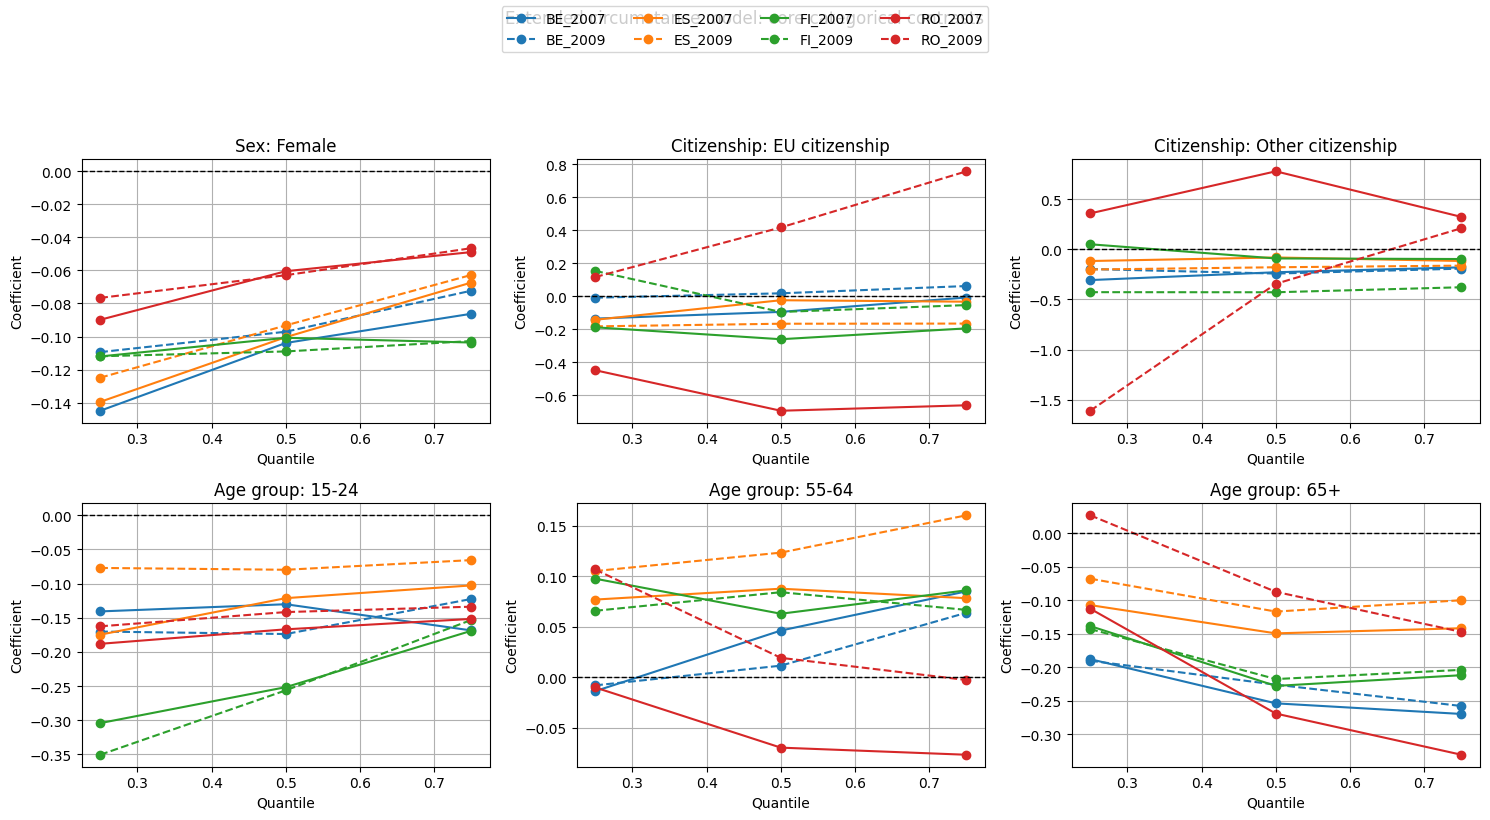

In [10]:
plot_vars_core = [
    "Sex: Female",
    "Citizenship: EU citizenship",
    "Citizenship: Other citizenship",
    "Age group: 15-24",
    "Age group: 55-64",
    "Age group: 65+"
]

plot_quantile_profiles(
    plot_vars_core,
    title="Extended circumstance model: core categorical contrasts",
    ncols=3,
    figsize=(15, 8)
)

Plot B: education contrasts

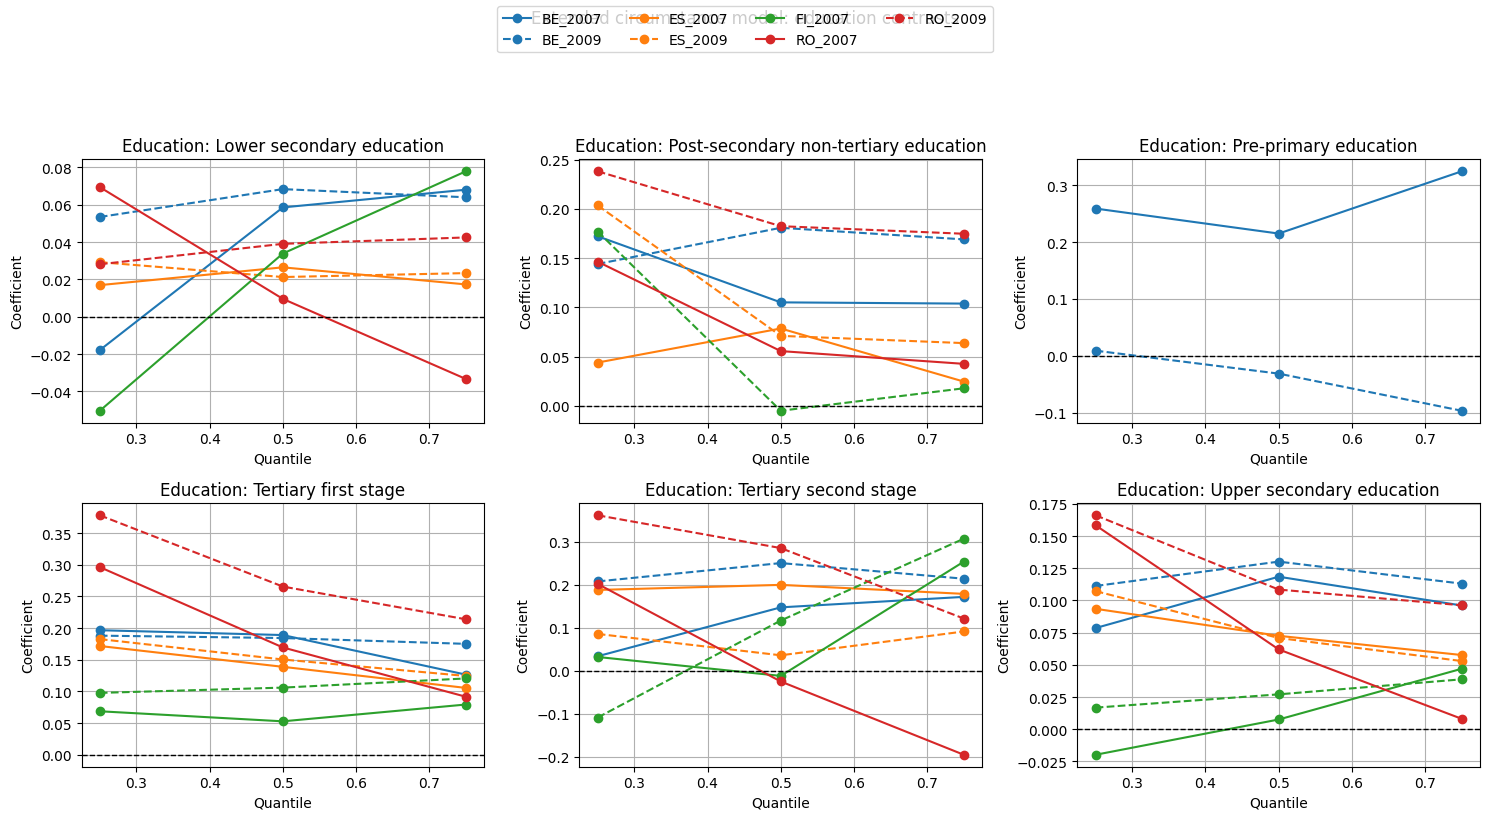

In [11]:
education_vars = [
    v for v in focal_summary["Variable"].unique()
    if v.startswith("Education:")
]

plot_quantile_profiles(
    education_vars,
    title="Extended circumstance model: education contrasts",
    ncols=3,
    figsize=(15, 8)
)

Plot C: health contrasts

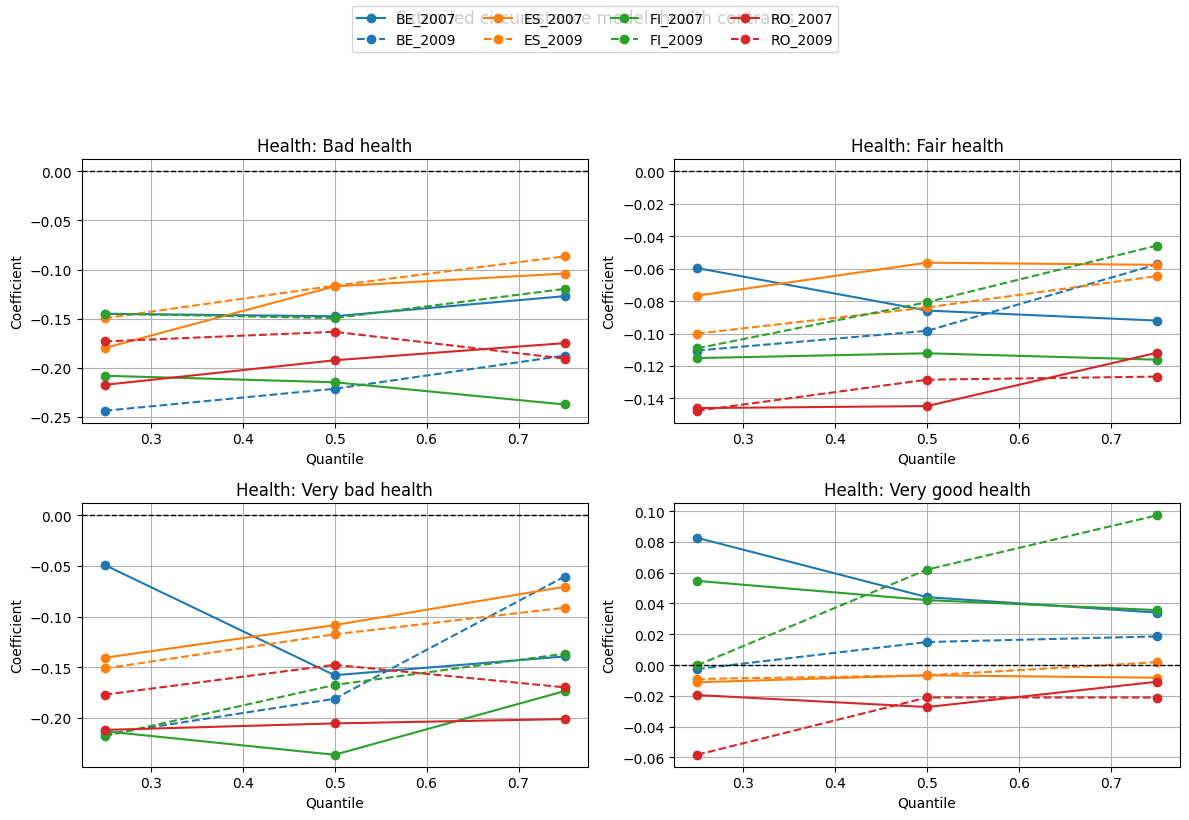

In [12]:
health_vars = [
    v for v in focal_summary["Variable"].unique()
    if v.startswith("Health:")
]

plot_quantile_profiles(
    health_vars,
    title="Extended circumstance model: health contrasts",
    ncols=2,
    figsize=(12, 8)
)

Plot D: regional summary

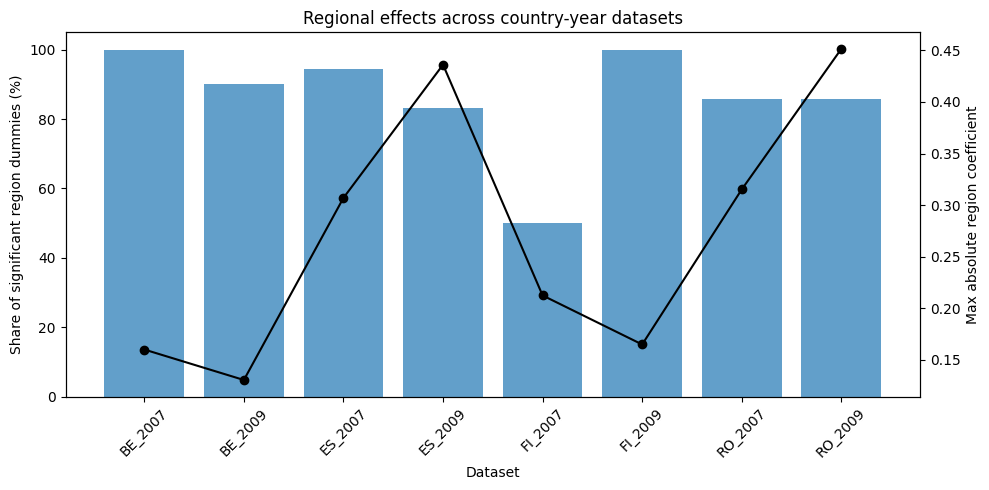

In [13]:
fig, ax1 = plt.subplots(figsize=(10, 5))

x = range(len(region_summary))

ax1.bar(
    x,
    region_summary["share_region_sig_any_5pct"],
    alpha=0.7,
    label="Share of significant region dummies (%)"
)

ax1.set_xticks(x)
ax1.set_xticklabels(region_summary["Dataset"], rotation=45)
ax1.set_ylabel("Share of significant region dummies (%)")
ax1.set_xlabel("Dataset")

ax2 = ax1.twinx()
ax2.plot(
    x,
    region_summary["max_abs_region_coef"],
    marker="o",
    color="black",
    label="Max absolute region coefficient"
)

ax2.set_ylabel("Max absolute region coefficient")

ax1.set_title("Regional effects across country-year datasets")

fig.tight_layout()
plt.show()

In [14]:
import pandas as pd
import numpy as np

# ======================================================
# Make sure required outputs exist
# ======================================================

required_objects = [
    "sample_summary",
    "category_counts",
    "focal_overview",
    "focal_summary",
    "region_summary",
    "top_region_effects",
    "top_changes_all",
    "top_significant_effects",
    "summary_all",
    "quantile_results"
]

missing = [obj for obj in required_objects if obj not in globals()]

if missing:
    raise ValueError(f"These objects are missing. Please run previous cells first: {missing}")

# ======================================================
# Avoid truncation in notebook display / print
# ======================================================

pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 300)
pd.set_option("display.max_colwidth", 200)

# ======================================================
# Prepare compact category count tables
# ======================================================

category_counts_clean = category_counts.copy()

# Main category counts I need
citizenship_counts = category_counts_clean[
    category_counts_clean["Variable"] == "Citizenship"
].copy()

age_group_counts = category_counts_clean[
    category_counts_clean["Variable"] == "Age group"
].copy()

education_counts = category_counts_clean[
    category_counts_clean["Variable"] == "Education"
].copy()

health_counts = category_counts_clean[
    category_counts_clean["Variable"] == "Health"
].copy()

# Small category warning table
# Important for cautious interpretation
small_categories = category_counts_clean[
    (category_counts_clean["Variable"].isin(["Citizenship", "Education", "Health"])) &
    (category_counts_clean["Category"].notna()) &
    (category_counts_clean["n"] < 100)
].copy()

small_categories = small_categories.sort_values(
    ["Variable", "Dataset", "n"]
)

# ======================================================
# Useful focused tables
# ======================================================

# Non-region focal results only
focal_no_region = focal_summary.copy()

# Region is not in focal_summary, but keep this name explicit
focal_no_region = focal_no_region.sort_values(["Variable", "Dataset"])

# Full non-region compact results
non_region_summary_all = summary_all[
    ~summary_all["Variable"].str.startswith("Region:", na=False)
].copy()

non_region_summary_all = non_region_summary_all.sort_values(
    ["Variable", "Dataset"]
)

# Full region compact results
region_full = summary_all[
    summary_all["Variable"].str.startswith("Region:", na=False)
].copy()

region_full = region_full.sort_values(
    ["Dataset", "Variable"]
)

# ======================================================
# Print complete outputs without ellipsis
# ======================================================

print("\n\n==================== 1. SAMPLE SUMMARY ====================\n")
print(sample_summary.to_string(index=False))

print("\n\n==================== 2. FOCAL OVERVIEW ====================\n")
print(focal_overview.to_string(index=False))

print("\n\n==================== 3. FULL FOCAL SUMMARY, NO TRUNCATION ====================\n")
print(focal_no_region.to_string(index=False))

print("\n\n==================== 4. REGION SUMMARY ====================\n")
print(region_summary.to_string(index=False))

print("\n\n==================== 5. TOP REGION EFFECTS ====================\n")
print(top_region_effects.to_string(index=False))

print("\n\n==================== 6. CITIZENSHIP COUNTS ====================\n")
print(citizenship_counts.to_string(index=False))

print("\n\n==================== 7. AGE GROUP COUNTS ====================\n")
print(age_group_counts.to_string(index=False))

print("\n\n==================== 8. EDUCATION COUNTS ====================\n")
print(education_counts.to_string(index=False))

print("\n\n==================== 9. HEALTH COUNTS ====================\n")
print(health_counts.to_string(index=False))

print("\n\n==================== 10. SMALL CATEGORY WARNING ====================\n")
print(small_categories.to_string(index=False))

print("\n\n==================== 11. TOP CHANGES ACROSS ALL VARIABLES ====================\n")
print(top_changes_all.to_string(index=False))

print("\n\n==================== 12. TOP SIGNIFICANT EFFECTS ====================\n")
print(top_significant_effects.to_string(index=False))

# ======================================================
# Save outputs to files
# ======================================================

excel_path = "/content/quantile_outputs_for_review_FULL.xlsx"
txt_path = "/content/quantile_outputs_for_review_FULL.txt"

with pd.ExcelWriter(excel_path, engine="openpyxl") as writer:
    sample_summary.to_excel(writer, sheet_name="sample_summary", index=False)
    focal_overview.to_excel(writer, sheet_name="focal_overview", index=False)
    focal_no_region.to_excel(writer, sheet_name="focal_summary_full", index=False)
    region_summary.to_excel(writer, sheet_name="region_summary", index=False)
    top_region_effects.to_excel(writer, sheet_name="top_region_effects", index=False)
    citizenship_counts.to_excel(writer, sheet_name="citizenship_counts", index=False)
    age_group_counts.to_excel(writer, sheet_name="age_group_counts", index=False)
    education_counts.to_excel(writer, sheet_name="education_counts", index=False)
    health_counts.to_excel(writer, sheet_name="health_counts", index=False)
    small_categories.to_excel(writer, sheet_name="small_category_warning", index=False)
    top_changes_all.to_excel(writer, sheet_name="top_changes_all", index=False)
    top_significant_effects.to_excel(writer, sheet_name="top_significant", index=False)
    non_region_summary_all.to_excel(writer, sheet_name="all_non_region_results", index=False)
    region_full.to_excel(writer, sheet_name="all_region_results", index=False)
    summary_all.to_excel(writer, sheet_name="all_compact_results", index=False)
    quantile_results.to_excel(writer, sheet_name="long_results", index=False)

# Also save a text version for copy-paste
with open(txt_path, "w", encoding="utf-8") as f:
    sections = [
        ("SAMPLE SUMMARY", sample_summary),
        ("FOCAL OVERVIEW", focal_overview),
        ("FULL FOCAL SUMMARY", focal_no_region),
        ("REGION SUMMARY", region_summary),
        ("TOP REGION EFFECTS", top_region_effects),
        ("CITIZENSHIP COUNTS", citizenship_counts),
        ("AGE GROUP COUNTS", age_group_counts),
        ("EDUCATION COUNTS", education_counts),
        ("HEALTH COUNTS", health_counts),
        ("SMALL CATEGORY WARNING", small_categories),
        ("TOP CHANGES ACROSS ALL VARIABLES", top_changes_all),
        ("TOP SIGNIFICANT EFFECTS", top_significant_effects),
    ]

    for title, table in sections:
        f.write("\n\n" + "=" * 80 + "\n")
        f.write(title + "\n")
        f.write("=" * 80 + "\n\n")
        f.write(table.to_string(index=False))
        f.write("\n")

print("\n\nFiles saved:")
print(excel_path)
print(txt_path)



==================== 1. SAMPLE SUMMARY ====================

Dataset  Raw n  Model n  Retained %
BE_2007  11974     9821        82.0
BE_2009  11559    10398        90.0
ES_2007  28445    25052        88.1
ES_2009  30270    26517        87.6
FI_2007  18686     9155        49.0
FI_2009  17644     9471        53.7
RO_2007  19848    18120        91.3
RO_2009  18612    17110        91.9


==================== 2. FOCAL OVERVIEW ====================

                                        Variable  mean_q25  mean_q50  mean_q75  mean_change  mean_abs_change  mean_abs_coef  datasets_sig_any
                  Citizenship: Other citizenship -0.306971 -0.102842 -0.074923     0.232048         0.277573       0.304496                 6
                     Citizenship: EU citizenship -0.104711 -0.112791 -0.037244     0.067467         0.174037       0.211831                 7
                                  Age group: 65+ -0.115282 -0.193708 -0.208032    -0.092750         0.092750       0.174550 

In [15]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 300)
pd.set_option("display.max_colwidth", 200)

output_dir = "/content/quantile_final_outputs"
os.makedirs(output_dir, exist_ok=True)

print("Output folder:", output_dir)

Output folder: /content/quantile_final_outputs


Cell 2：Table 1，Analytical sample size

In [16]:
# ======================================================
# Table 1: Analytical sample size
# ======================================================

table_1_sample_size = sample_summary.copy()

# Clean dataset labels for thesis display
table_1_sample_size["Dataset"] = table_1_sample_size["Dataset"].str.replace("_", " ")

table_1_sample_size = table_1_sample_size[
    ["Dataset", "Raw n", "Model n", "Retained %"]
]

display(table_1_sample_size)

# Save
table_1_sample_size.to_csv(
    f"{output_dir}/Table_1_analytical_sample_size.csv",
    index=False
)

table_1_sample_size.to_excel(
    f"{output_dir}/Table_1_analytical_sample_size.xlsx",
    index=False
)

print("Saved Table 1.")

,Dataset,Raw n,Model n,Retained %
0,BE 2007,11974,9821,82.0
81,BE 2009,11559,10398,90.0
162,ES 2007,28445,25052,88.1
264,ES 2009,30270,26517,87.6
366,FI 2007,18686,9155,49.0
423,FI 2009,17644,9471,53.7
480,RO 2007,19848,18120,91.3
549,RO 2009,18612,17110,91.9


Saved Table 1.


In [17]:
# ======================================================
# Table 2: Selected non-regional coefficient summary
# ======================================================

selected_vars = [
    "Age group: 15-24",
    "Age group: 65+",
    "Sex: Female",
    "Education: Tertiary first stage",
    "Education: Upper secondary education",
    "Health: Bad health",
    "Health: Very bad health"
]

reference_map = {
    "Age group: 15-24": "Age 25-54",
    "Age group: 65+": "Age 25-54",
    "Sex: Female": "Male",
    "Education: Tertiary first stage": "Primary education",
    "Education: Upper secondary education": "Primary education",
    "Health: Bad health": "Good health",
    "Health: Very bad health": "Good health"
}

pattern_map = {
    "Age group: 15-24": "Negative relative to age 25-54",
    "Age group: 65+": "More negative at median / upper quantile",
    "Sex: Female": "Negative across all quantiles",
    "Education: Tertiary first stage": "Positive, stronger at lower quantile",
    "Education: Upper secondary education": "Positive but smaller",
    "Health: Bad health": "Negative across all quantiles",
    "Health: Very bad health": "Negative across all quantiles"
}

table_2 = focal_overview[
    focal_overview["Variable"].isin(selected_vars)
].copy()

# Keep selected order
table_2["Variable"] = pd.Categorical(
    table_2["Variable"],
    categories=selected_vars,
    ordered=True
)

table_2 = table_2.sort_values("Variable")

table_2["Reference category"] = table_2["Variable"].astype(str).map(reference_map)
table_2["Main pattern"] = table_2["Variable"].astype(str).map(pattern_map)

table_2 = table_2[
    [
        "Variable",
        "Reference category",
        "mean_q25",
        "mean_q50",
        "mean_q75",
        "datasets_sig_any",
        "Main pattern"
    ]
].copy()

table_2 = table_2.rename(columns={
    "mean_q25": "Mean coefficient q25",
    "mean_q50": "Mean coefficient q50",
    "mean_q75": "Mean coefficient q75",
    "datasets_sig_any": "Datasets significant"
})

# Round coefficients
for col in ["Mean coefficient q25", "Mean coefficient q50", "Mean coefficient q75"]:
    table_2[col] = table_2[col].round(3)

display(table_2)

# Save
table_2.to_csv(
    f"{output_dir}/Table_2_selected_nonregional_coefficients.csv",
    index=False
)

table_2.to_excel(
    f"{output_dir}/Table_2_selected_nonregional_coefficients.xlsx",
    index=False
)

print("Saved Table 2.")

,Variable,Reference category,Mean coefficient q25,Mean coefficient q50,Mean coefficient q75,Datasets significant,Main pattern
0,Age group: 15-24,Age 25-54,-0.196,-0.165,-0.133,8,Negative relative to age 25-54
2,Age group: 65+,Age 25-54,-0.115,-0.194,-0.208,8,More negative at median / upper quantile
15,Sex: Female,Male,-0.114,-0.091,-0.074,8,Negative across all quantiles
8,Education: Tertiary first stage,Primary education,0.197,0.157,0.130,8,"Positive, stronger at lower quantile"
10,Education: Upper secondary education,Primary education,0.089,0.075,0.064,7,Positive but smaller
11,Health: Bad health,Good health,-0.183,-0.165,-0.153,8,Negative across all quantiles
13,Health: Very bad health,Good health,-0.172,-0.165,-0.130,8,Negative across all quantiles


Saved Table 2.


Cell 4：Figure 1，Selected coefficient profiles，2 × 3

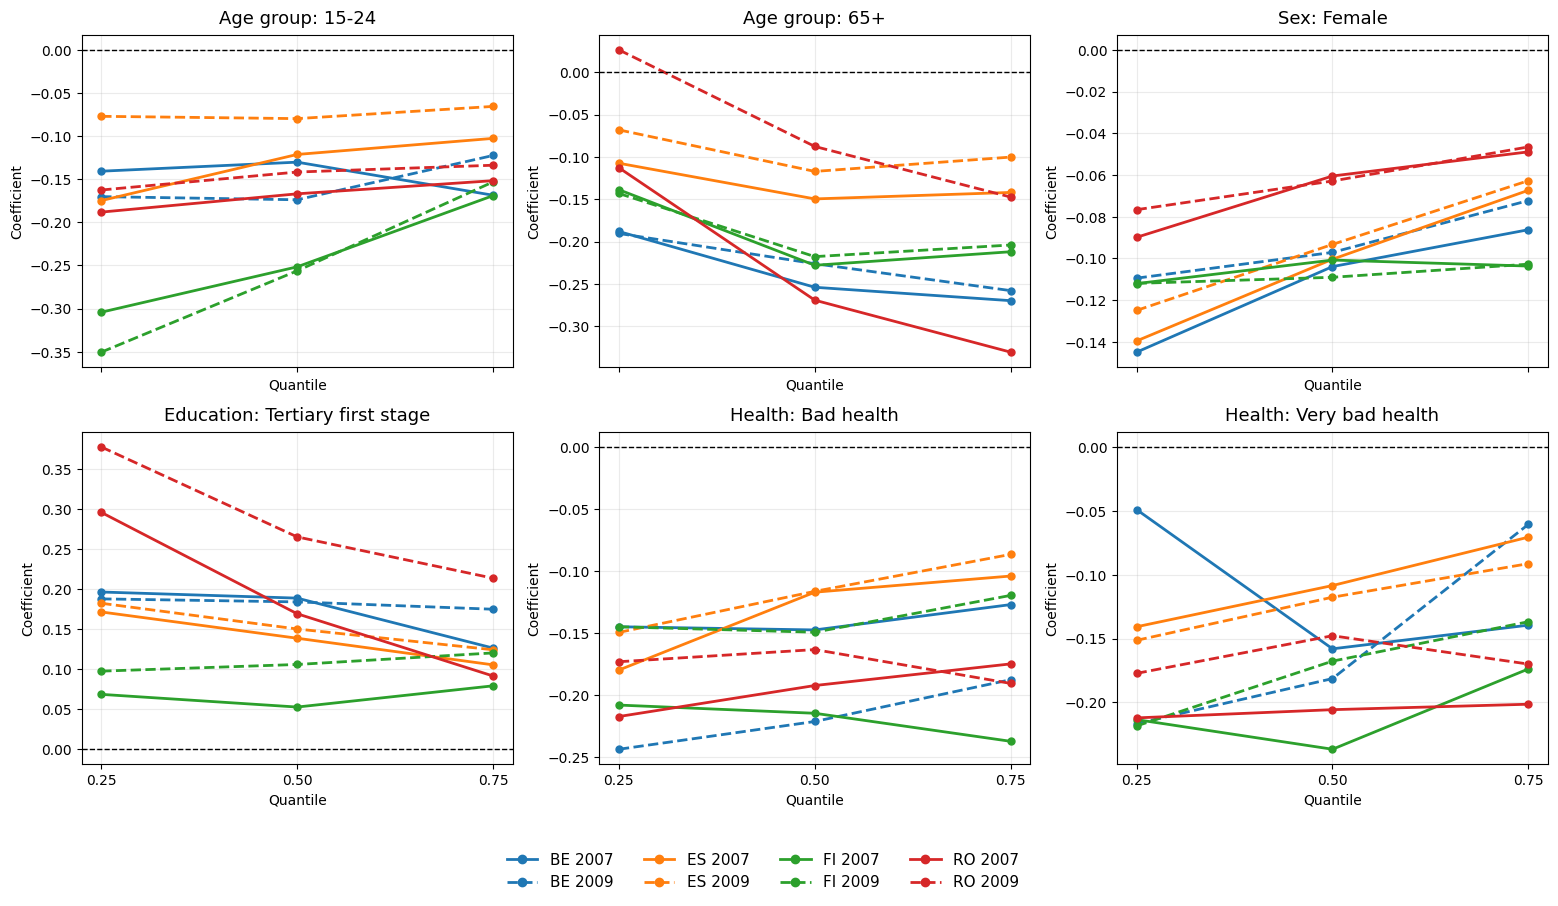

Saved Figure 1:
/content/quantile_final_outputs/Figure_1_selected_coefficient_profiles_clean.png
/content/quantile_final_outputs/Figure_1_selected_coefficient_profiles_clean.pdf


In [18]:
# ======================================================
# Figure 1: Selected coefficient profiles (clean thesis version)
# ======================================================

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

country_colors = {
    "BE": "tab:blue",
    "ES": "tab:orange",
    "FI": "tab:green",
    "RO": "tab:red"
}

year_linestyles = {
    "2007": "-",
    "2009": "--"
}

def get_country_year(dataset):
    country, year = dataset.split("_")
    return country, year

figure_1_vars = [
    "Age group: 15-24",
    "Age group: 65+",
    "Sex: Female",
    "Education: Tertiary first stage",
    "Health: Bad health",
    "Health: Very bad health"
]

fig, axes = plt.subplots(2, 3, figsize=(16, 9), sharex=True)
axes = axes.flatten()

for i, var in enumerate(figure_1_vars):
    ax = axes[i]
    temp = focal_summary[focal_summary["Variable"] == var].copy()

    for dataset in sorted(temp["Dataset"].unique()):
        row = temp[temp["Dataset"] == dataset].iloc[0]
        country, year = get_country_year(dataset)

        ax.plot(
            [0.25, 0.50, 0.75],
            [row["coef_q25"], row["coef_q50"], row["coef_q75"]],
            marker="o",
            linewidth=2,
            markersize=5,
            color=country_colors[country],
            linestyle=year_linestyles[year]
        )

    ax.axhline(0, color="black", linestyle="--", linewidth=1)
    ax.set_title(var, fontsize=13, pad=8)
    ax.set_xticks([0.25, 0.50, 0.75])
    ax.set_xlabel("Quantile")
    ax.set_ylabel("Coefficient")
    ax.grid(True, alpha=0.25)

# ---- custom legend: cleaner and more stable ----
legend_elements = [
    Line2D([0], [0], color="tab:blue", lw=2, linestyle="-", marker="o", label="BE 2007"),
    Line2D([0], [0], color="tab:blue", lw=2, linestyle="--", marker="o", label="BE 2009"),
    Line2D([0], [0], color="tab:orange", lw=2, linestyle="-", marker="o", label="ES 2007"),
    Line2D([0], [0], color="tab:orange", lw=2, linestyle="--", marker="o", label="ES 2009"),
    Line2D([0], [0], color="tab:green", lw=2, linestyle="-", marker="o", label="FI 2007"),
    Line2D([0], [0], color="tab:green", lw=2, linestyle="--", marker="o", label="FI 2009"),
    Line2D([0], [0], color="tab:red", lw=2, linestyle="-", marker="o", label="RO 2007"),
    Line2D([0], [0], color="tab:red", lw=2, linestyle="--", marker="o", label="RO 2009"),
]

fig.legend(
    handles=legend_elements,
    loc="lower center",
    ncol=4,
    frameon=False,
    bbox_to_anchor=(0.5, -0.01),
    fontsize=11
)

# Leave room at the bottom for the legend
plt.tight_layout(rect=[0.02, 0.08, 1, 1])

fig_path_png = f"{output_dir}/Figure_1_selected_coefficient_profiles_clean.png"
fig_path_pdf = f"{output_dir}/Figure_1_selected_coefficient_profiles_clean.pdf"

plt.savefig(fig_path_png, dpi=300, bbox_inches="tight")
plt.savefig(fig_path_pdf, bbox_inches="tight")

plt.show()

print("Saved Figure 1:")
print(fig_path_png)
print(fig_path_pdf)

Cell 5：Figure 2，Regional summary

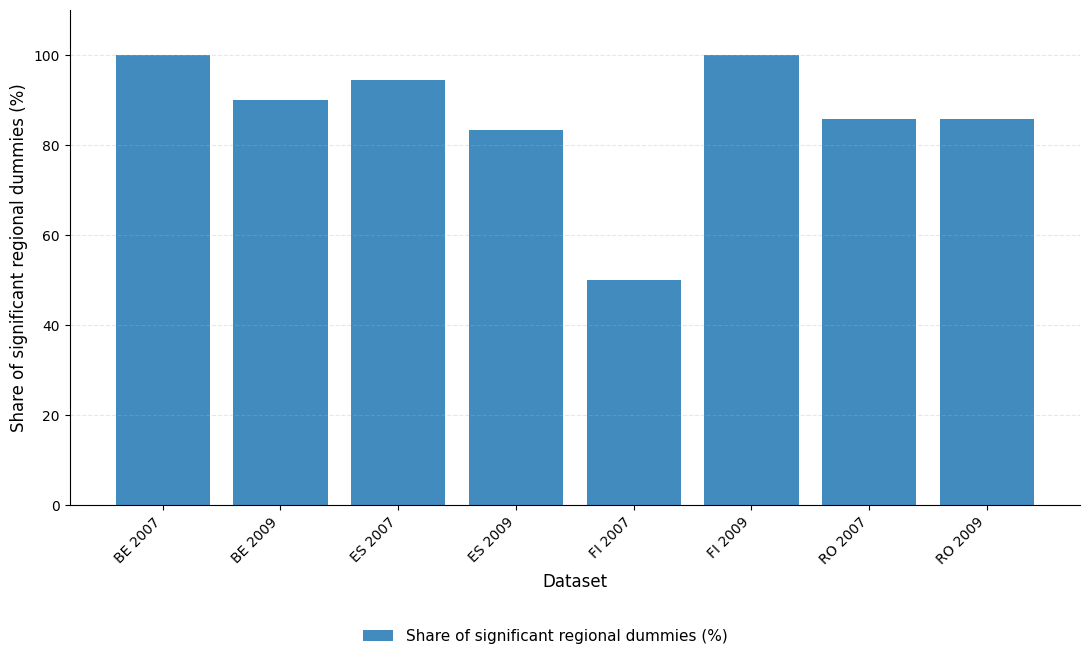

Saved Figure 2:
/content/quantile_final_outputs/Figure_2_regional_summary_bar_only.png
/content/quantile_final_outputs/Figure_2_regional_summary_bar_only.pdf


In [19]:
# ======================================================
# Figure 2: Regional summary (bar chart only)
# ======================================================

import numpy as np
import matplotlib.pyplot as plt

# Make a copy and define x positions
region_plot = region_summary.copy()
x = np.arange(len(region_plot))

# Labels with space instead of underscore
xlabels = [d.replace("_", " ") for d in region_plot["Dataset"]]

# Create figure
fig, ax1 = plt.subplots(figsize=(11, 6.5))

# --- Bars: share of significant regional dummies ---
bars = ax1.bar(
    x,
    region_plot["share_region_sig_any_5pct"],
    width=0.8,
    alpha=0.85,
    label="Share of significant regional dummies (%)"
)

ax1.set_ylabel("Share of significant regional dummies (%)", fontsize=12)
ax1.set_xlabel("Dataset", fontsize=12)
ax1.set_xticks(x)
ax1.set_xticklabels(xlabels, rotation=45, ha="right")
ax1.set_ylim(0, 110)

# Light grid on y only
ax1.grid(axis="y", linestyle="--", alpha=0.3)

# Remove top and right spines for cleaner look
ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)

# --- Legend at bottom ---
handles1, labels1 = ax1.get_legend_handles_labels()

fig.legend(
    handles1,
    labels1,
    loc="lower center",
    ncol=1,
    frameon=False,
    bbox_to_anchor=(0.5, -0.02),
    fontsize=11
)

# No long title inside the figure
# ax1.set_title("Regional contrasts across country-year models", fontsize=14, pad=10)

plt.tight_layout(rect=[0, 0.06, 1, 1])

fig_path_png = f"{output_dir}/Figure_2_regional_summary_bar_only.png"
fig_path_pdf = f"{output_dir}/Figure_2_regional_summary_bar_only.pdf"

plt.savefig(fig_path_png, dpi=300, bbox_inches="tight")
plt.savefig(fig_path_pdf, bbox_inches="tight")

plt.show()

print("Saved Figure 2:")
print(fig_path_png)
print(fig_path_pdf)

Cell 6：Appendix Table A1，Full focal coefficients

In [20]:
# ======================================================
# Appendix Table A1: Full focal quantile coefficients
# ======================================================

appendix_A1_focal = focal_summary.copy()
appendix_A1_focal["Dataset"] = appendix_A1_focal["Dataset"].str.replace("_", " ")

display(appendix_A1_focal)

appendix_A1_focal.to_csv(
    f"{output_dir}/Appendix_A1_full_focal_quantile_coefficients.csv",
    index=False
)

appendix_A1_focal.to_excel(
    f"{output_dir}/Appendix_A1_full_focal_quantile_coefficients.xlsx",
    index=False
)

print("Saved Appendix Table A1.")

Quantile,Dataset,Variable,coef_q25,sig_q25,coef_q50,sig_q50,coef_q75,sig_q75,q75_minus_q25,abs_change,mean_abs_coef,n_sig_5pct,Interpretation pattern
0,BE 2007,Age group: 15-24,-0.140681,***,-0.130193,***,-0.168548,***,-0.027867,0.027867,0.146474,3,Upper-tail negative association
27,BE 2009,Age group: 15-24,-0.170162,***,-0.173796,***,-0.122443,***,0.047719,0.047719,0.155467,3,Lower-tail negative association
54,ES 2007,Age group: 15-24,-0.174761,***,-0.121260,***,-0.102625,***,0.072136,0.072136,0.132882,3,Lower-tail negative association
88,ES 2009,Age group: 15-24,-0.077046,***,-0.079713,***,-0.065558,***,0.011487,0.011487,0.074106,3,Lower-tail negative association
122,FI 2007,Age group: 15-24,-0.304188,***,-0.251556,***,-0.169016,***,0.135172,0.135172,0.241587,3,Lower-tail negative association
141,FI 2009,Age group: 15-24,-0.350506,***,-0.256205,***,-0.153086,***,0.197421,0.197421,0.253266,3,Lower-tail negative association
160,RO 2007,Age group: 15-24,-0.188112,***,-0.166905,***,-0.151668,***,0.036444,0.036444,0.168895,3,Lower-tail negative association
183,RO 2009,Age group: 15-24,-0.162497,***,-0.141641,***,-0.133759,***,0.028737,0.028737,0.145966,3,Lower-tail negative association
1,BE 2007,Age group: 55-64,-0.013933,,0.046046,*,0.084845,***,0.098777,0.098777,0.048274,2,"Sign reversal: negative at q25, positive at q75"
28,BE 2009,Age group: 55-64,-0.008208,,0.011303,,0.063680,**,0.071887,0.071887,0.027730,1,"Sign reversal: negative at q25, positive at q75"


Saved Appendix Table A1.


Cell 7：Appendix Table A2，Full regional coefficients

In [21]:
# ======================================================
# Appendix Table A2: Full regional coefficients
# ======================================================

appendix_A2_region = summary_all[
    summary_all["Variable"].str.startswith("Region:", na=False)
].copy()

appendix_A2_region = appendix_A2_region.sort_values(["Dataset", "Variable"])
appendix_A2_region["Dataset"] = appendix_A2_region["Dataset"].str.replace("_", " ")

appendix_A2_region = appendix_A2_region[
    [
        "Dataset",
        "Variable",
        "coef_q25",
        "sig_q25",
        "coef_q50",
        "sig_q50",
        "coef_q75",
        "sig_q75",
        "q75_minus_q25",
        "abs_change",
        "mean_abs_coef",
        "n_sig_5pct",
        "Interpretation pattern"
    ]
]

display(appendix_A2_region)

appendix_A2_region.to_csv(
    f"{output_dir}/Appendix_A2_full_regional_coefficients.csv",
    index=False
)

appendix_A2_region.to_excel(
    f"{output_dir}/Appendix_A2_full_regional_coefficients.xlsx",
    index=False
)

print("Saved Appendix Table A2.")

Quantile,Dataset,Variable,coef_q25,sig_q25,coef_q50,sig_q50,coef_q75,sig_q75,q75_minus_q25,abs_change,mean_abs_coef,n_sig_5pct,Interpretation pattern
15,BE 2007,Region: BE21,0.013226,,-0.067938,*,-0.194113,***,-0.207338,0.207338,0.091759,2,"Sign reversal: positive at q25, negative at q75"
16,BE 2007,Region: BE22,0.016858,,-0.081707,*,-0.157557,***,-0.174415,0.174415,0.085374,2,"Sign reversal: positive at q25, negative at q75"
17,BE 2007,Region: BE23,0.032192,,-0.060993,.,-0.179299,***,-0.211491,0.211491,0.090828,1,"Sign reversal: positive at q25, negative at q75"
18,BE 2007,Region: BE24,-0.069329,,-0.006821,,-0.109451,***,-0.040123,0.040123,0.061867,1,Upper-tail negative association
19,BE 2007,Region: BE25,-0.023829,,-0.115820,***,-0.273060,***,-0.249231,0.249231,0.137569,2,Upper-tail negative association
20,BE 2007,Region: BE31,-0.002492,,-0.149709,**,-0.267221,***,-0.264729,0.264729,0.139807,2,Upper-tail negative association
21,BE 2007,Region: BE32,-0.053181,,-0.115762,***,-0.311437,***,-0.258256,0.258256,0.160127,2,Upper-tail negative association
22,BE 2007,Region: BE33,-0.037073,,-0.114499,**,-0.264495,***,-0.227422,0.227422,0.138689,2,Upper-tail negative association
23,BE 2007,Region: BE34,0.034632,,-0.035673,,-0.143363,**,-0.177994,0.177994,0.071222,1,"Sign reversal: positive at q25, negative at q75"
24,BE 2007,Region: BE35,-0.023753,,-0.103614,*,-0.230519,***,-0.206766,0.206766,0.119295,2,Upper-tail negative association


Saved Appendix Table A2.


Cell 8：Appendix Table A3，Category counts and small-cell warnings

In [22]:
# ======================================================
# Appendix Table A3: Category counts and small-cell warnings
# ======================================================

appendix_A3_counts = category_counts[
    category_counts["Variable"].isin([
        "Citizenship",
        "Education",
        "Health",
        "Age group"
    ])
].copy()

appendix_A3_counts["Dataset"] = appendix_A3_counts["Dataset"].str.replace("_", " ")

small_cell_warning = category_counts[
    (category_counts["Variable"].isin(["Citizenship", "Education", "Health"])) &
    (category_counts["Category"].notna()) &
    (category_counts["n"] < 100)
].copy()

small_cell_warning["Dataset"] = small_cell_warning["Dataset"].str.replace("_", " ")

print("Category counts:")
display(appendix_A3_counts)

print("Small-cell warnings:")
display(small_cell_warning)

# Save separately
appendix_A3_counts.to_csv(
    f"{output_dir}/Appendix_A3_category_counts.csv",
    index=False
)

appendix_A3_counts.to_excel(
    f"{output_dir}/Appendix_A3_category_counts.xlsx",
    index=False
)

small_cell_warning.to_csv(
    f"{output_dir}/Appendix_A3_small_cell_warnings.csv",
    index=False
)

small_cell_warning.to_excel(
    f"{output_dir}/Appendix_A3_small_cell_warnings.xlsx",
    index=False
)

print("Saved Appendix Table A3 files.")

Category counts:


,Dataset,Variable,Category,n,Percent
2,BE 2007,Citizenship,National citizenship,10687,89.25
3,BE 2007,Citizenship,EU citizenship,700,5.85
4,BE 2007,Citizenship,Other citizenship,398,3.32
5,BE 2007,Citizenship,NaN,189,1.58
6,BE 2007,Age group,25-54,6147,51.34
7,BE 2007,Age group,65+,2593,21.66
8,BE 2007,Age group,55-64,1823,15.22
9,BE 2007,Age group,15-24,1411,11.78
10,BE 2007,Education,Upper secondary education,3649,30.47
11,BE 2007,Education,Tertiary first stage,3414,28.51


Small-cell warnings:


,Dataset,Variable,Category,n,Percent
16,BE 2007,Education,Tertiary second stage,80,0.67
17,BE 2007,Education,Pre-primary education,11,0.09
195,FI 2009,Education,Post-secondary non-tertiary education,68,0.39
211,RO 2007,Citizenship,EU citizenship,12,0.06
212,RO 2007,Citizenship,Other citizenship,3,0.02
223,RO 2007,Education,Tertiary second stage,21,0.11
241,RO 2009,Citizenship,Other citizenship,7,0.04
242,RO 2009,Citizenship,EU citizenship,6,0.03
253,RO 2009,Education,Tertiary second stage,14,0.08


Saved Appendix Table A3 files.


Cell 9：一次性打包成一个 Excel 文件

In [23]:
# ======================================================
# Save all final outputs into one Excel workbook
# ======================================================

final_excel_path = f"{output_dir}/quantile_final_tables_for_thesis.xlsx"

with pd.ExcelWriter(final_excel_path, engine="openpyxl") as writer:
    table_1_sample_size.to_excel(writer, sheet_name="Table_1_sample_size", index=False)
    table_2.to_excel(writer, sheet_name="Table_2_selected_summary", index=False)
    appendix_A1_focal.to_excel(writer, sheet_name="Appendix_A1_focal", index=False)
    appendix_A2_region.to_excel(writer, sheet_name="Appendix_A2_region", index=False)
    appendix_A3_counts.to_excel(writer, sheet_name="Appendix_A3_counts", index=False)
    small_cell_warning.to_excel(writer, sheet_name="Appendix_A3_small_cells", index=False)
    region_summary.to_excel(writer, sheet_name="Region_summary_raw", index=False)

print("Saved final Excel workbook:")
print(final_excel_path)

Saved final Excel workbook:
/content/quantile_final_outputs/quantile_final_tables_for_thesis.xlsx


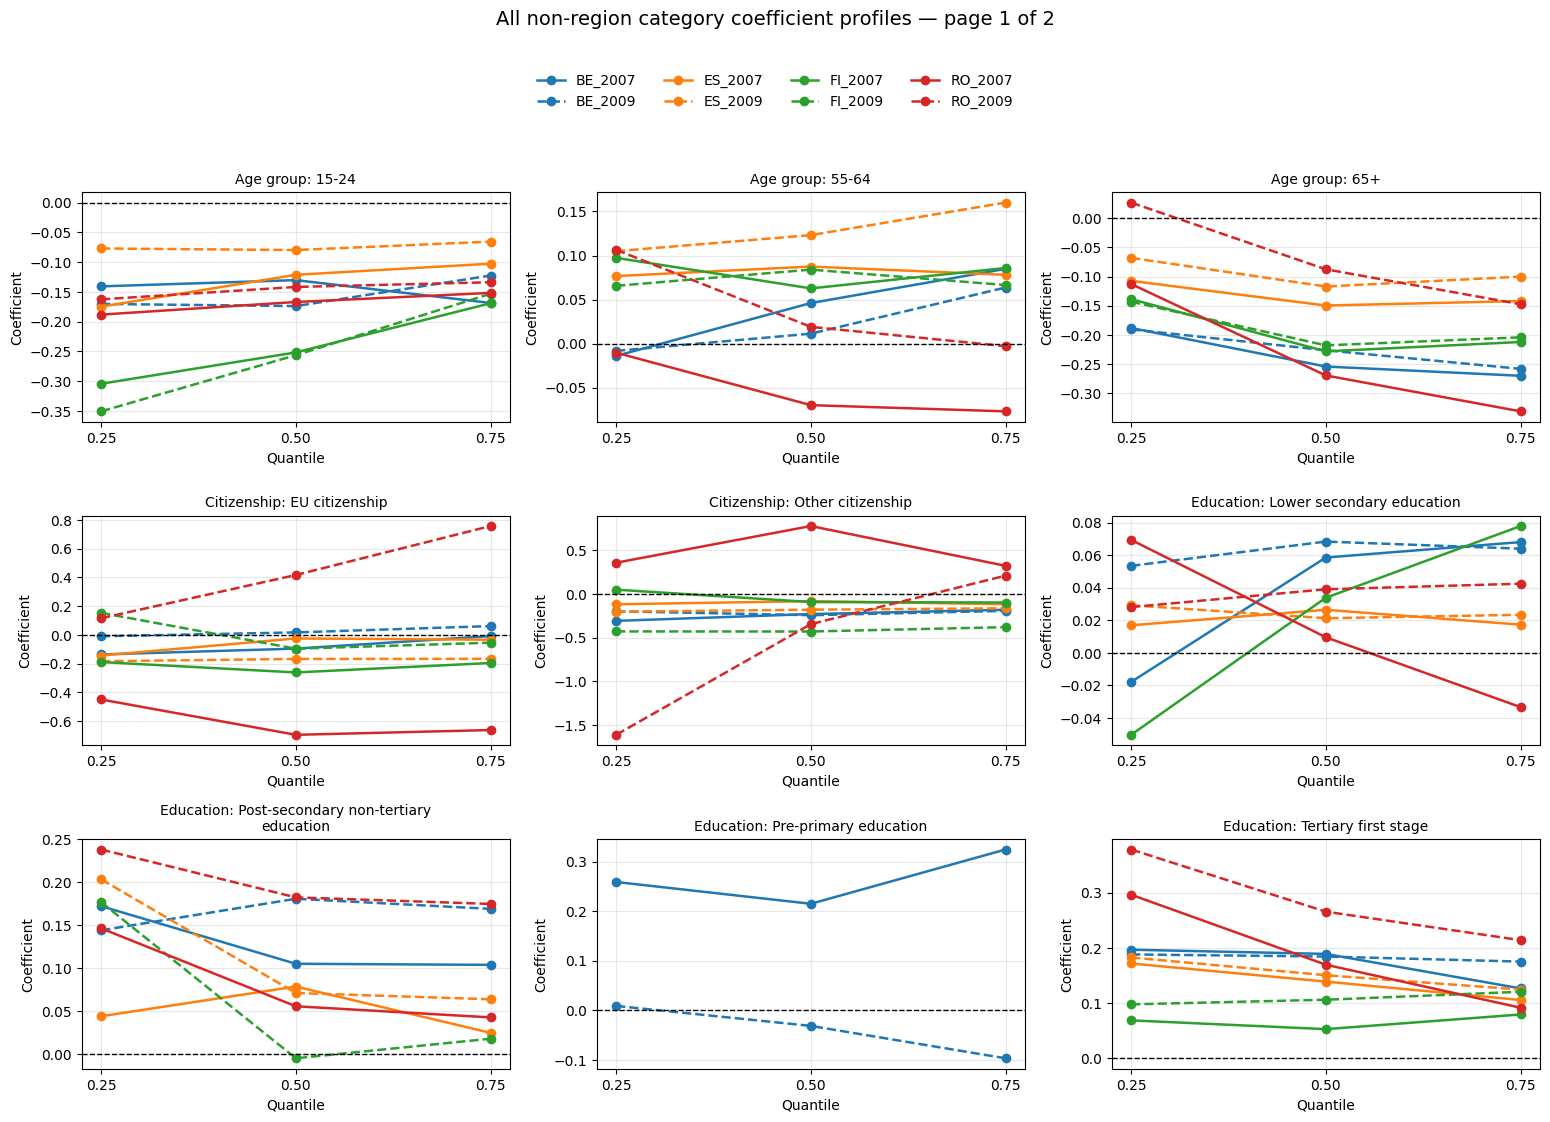

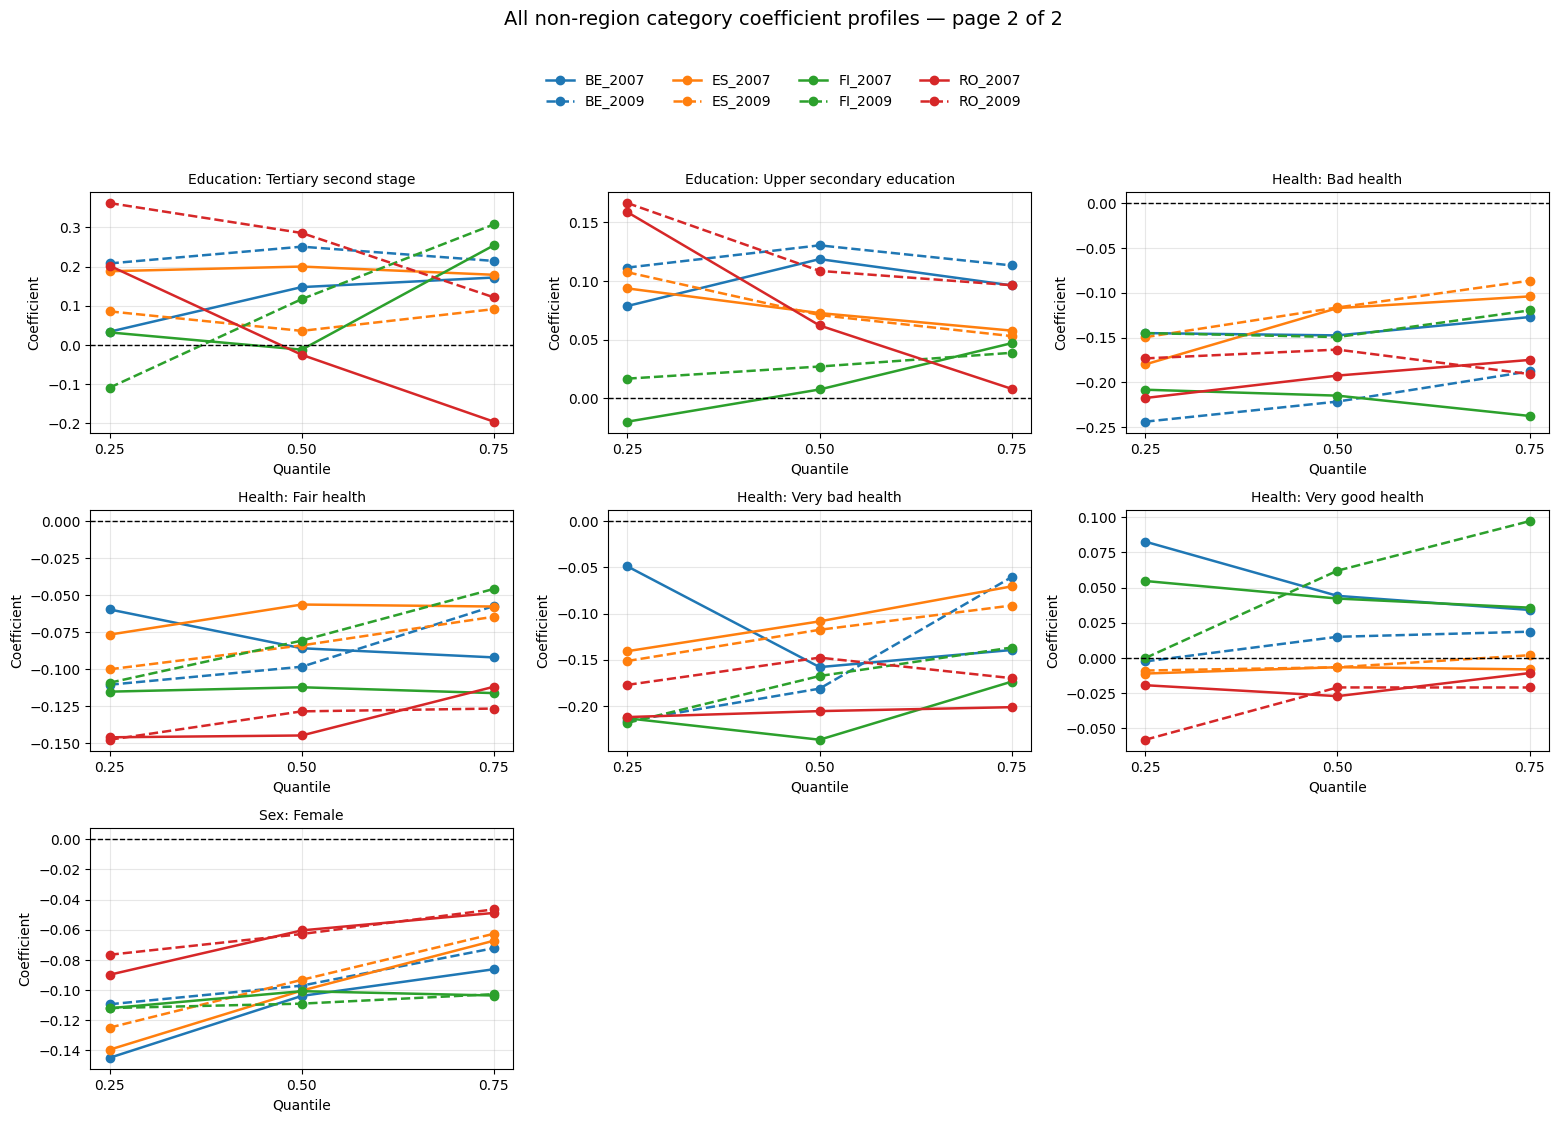

Saved: figures/all_category_profiles/all_non_region_category_profiles.pdf


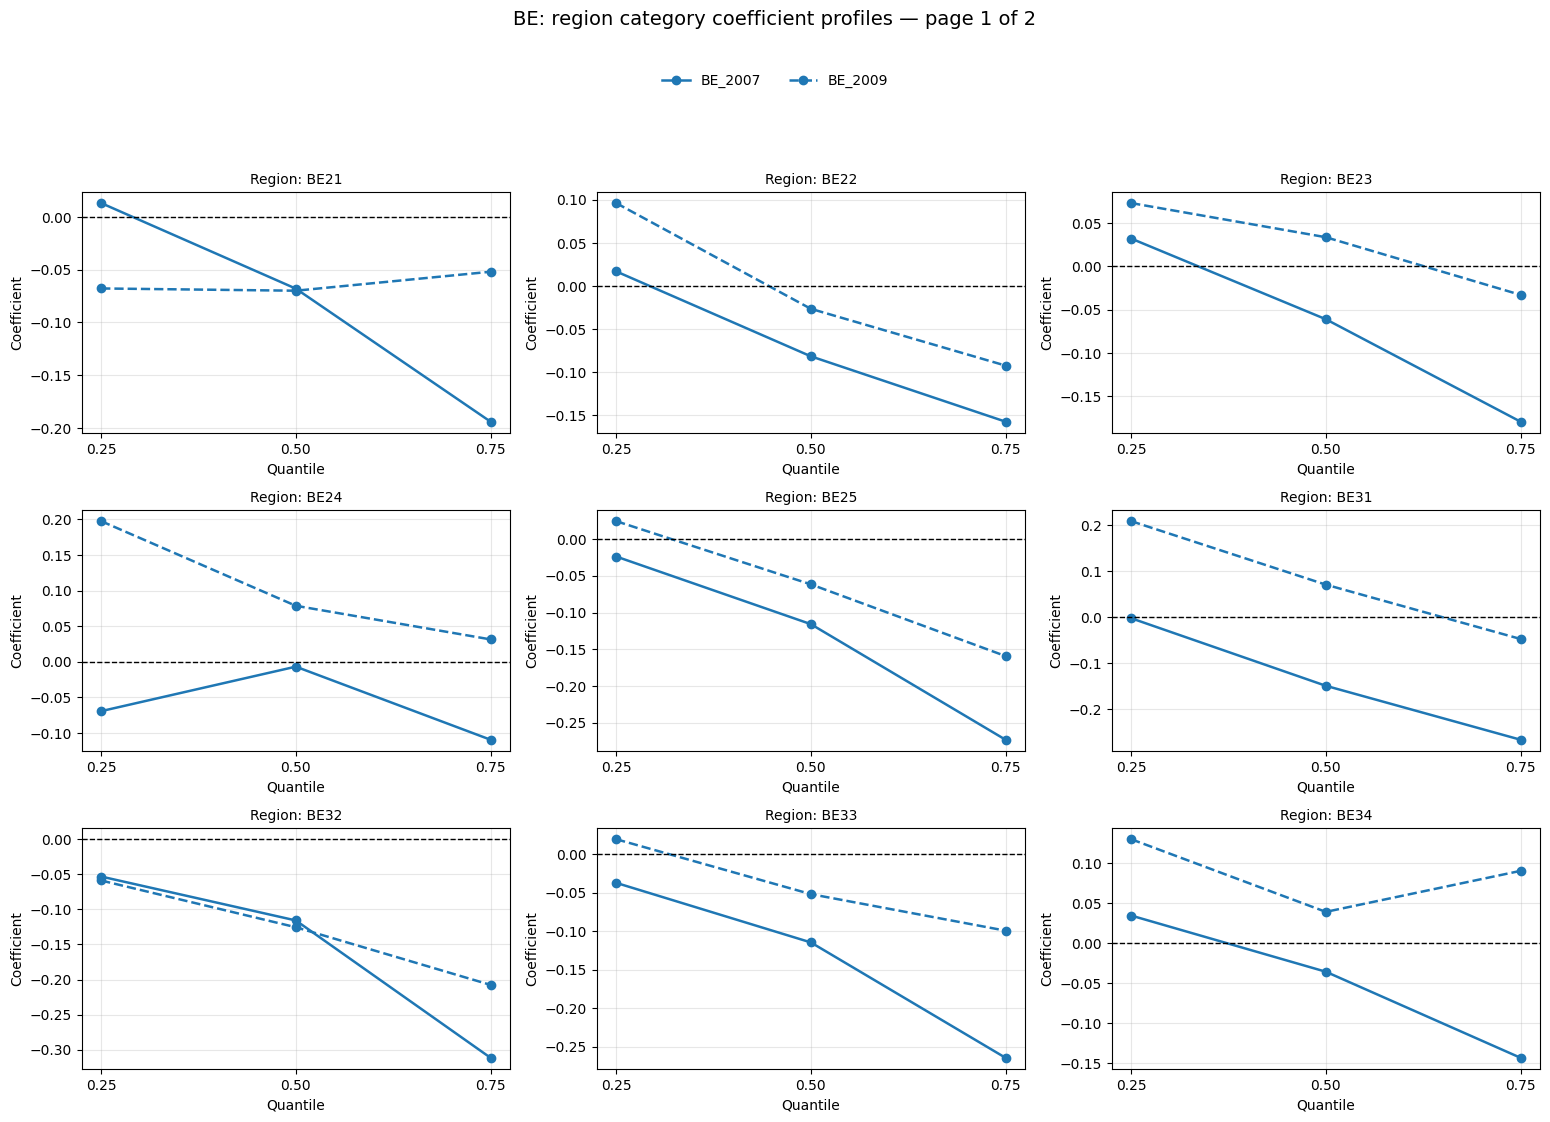

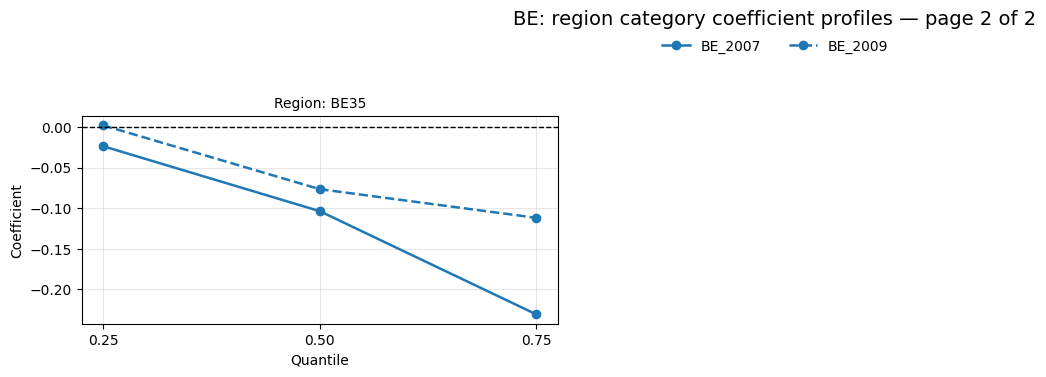

Saved: figures/all_category_profiles/BE_region_category_profiles.pdf


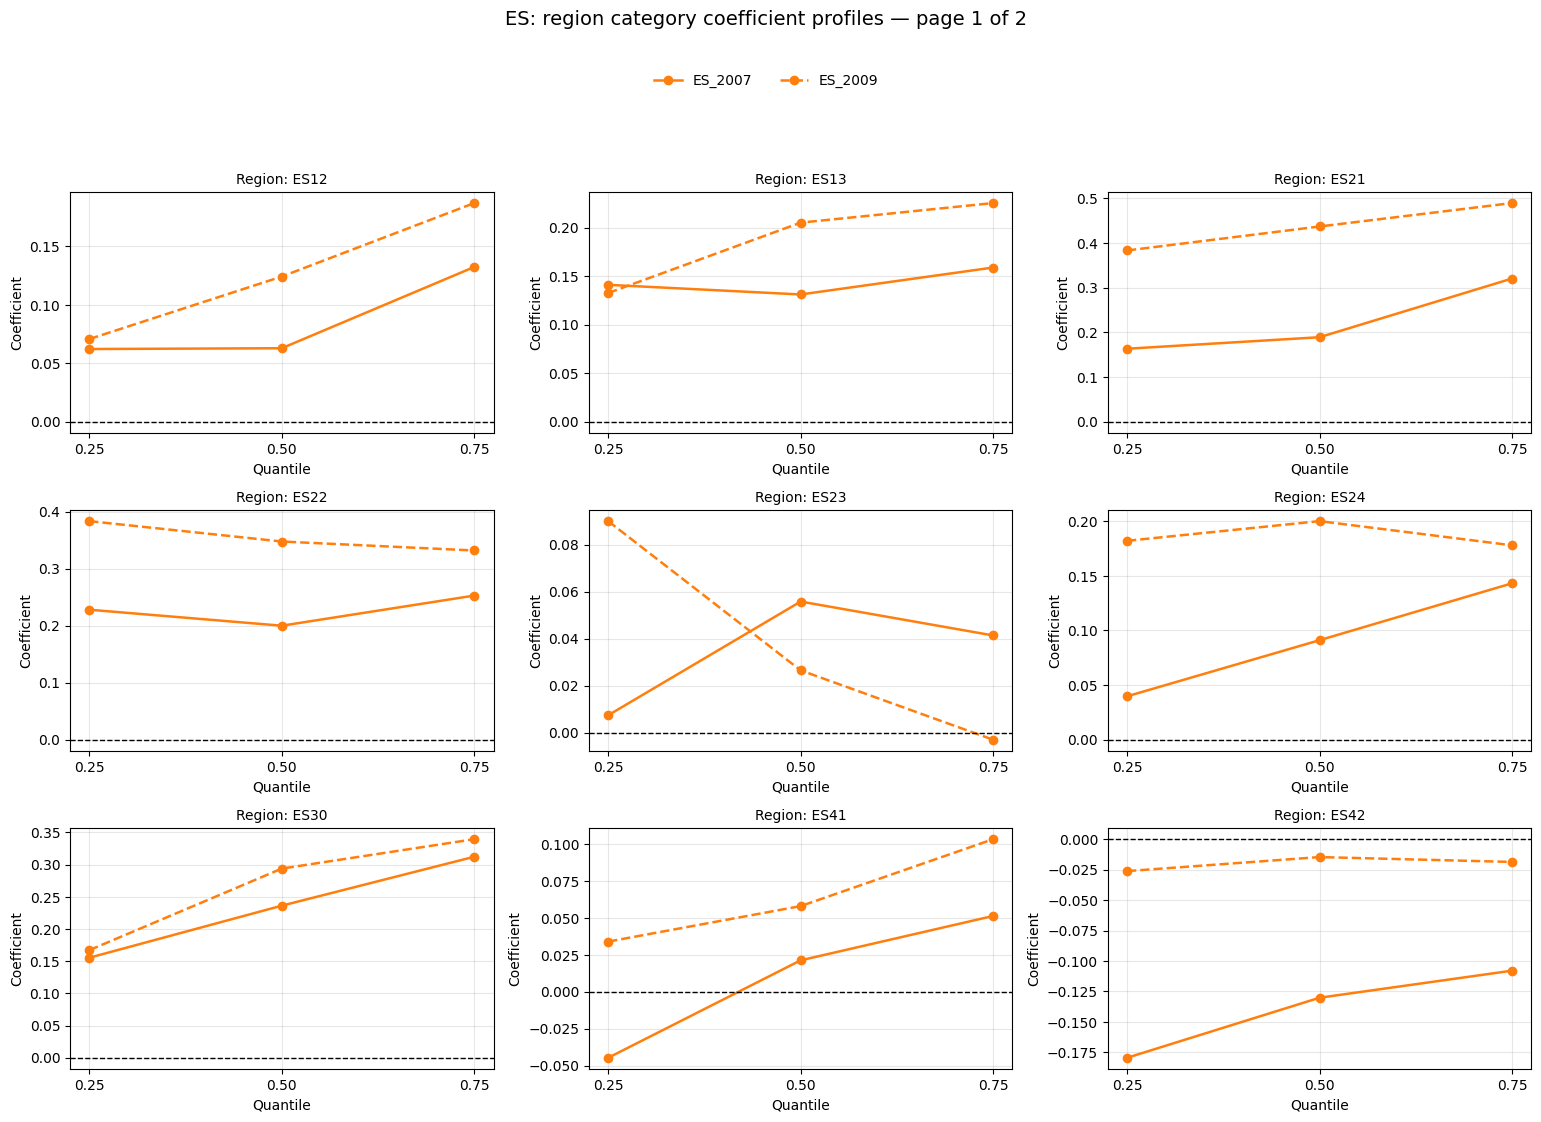

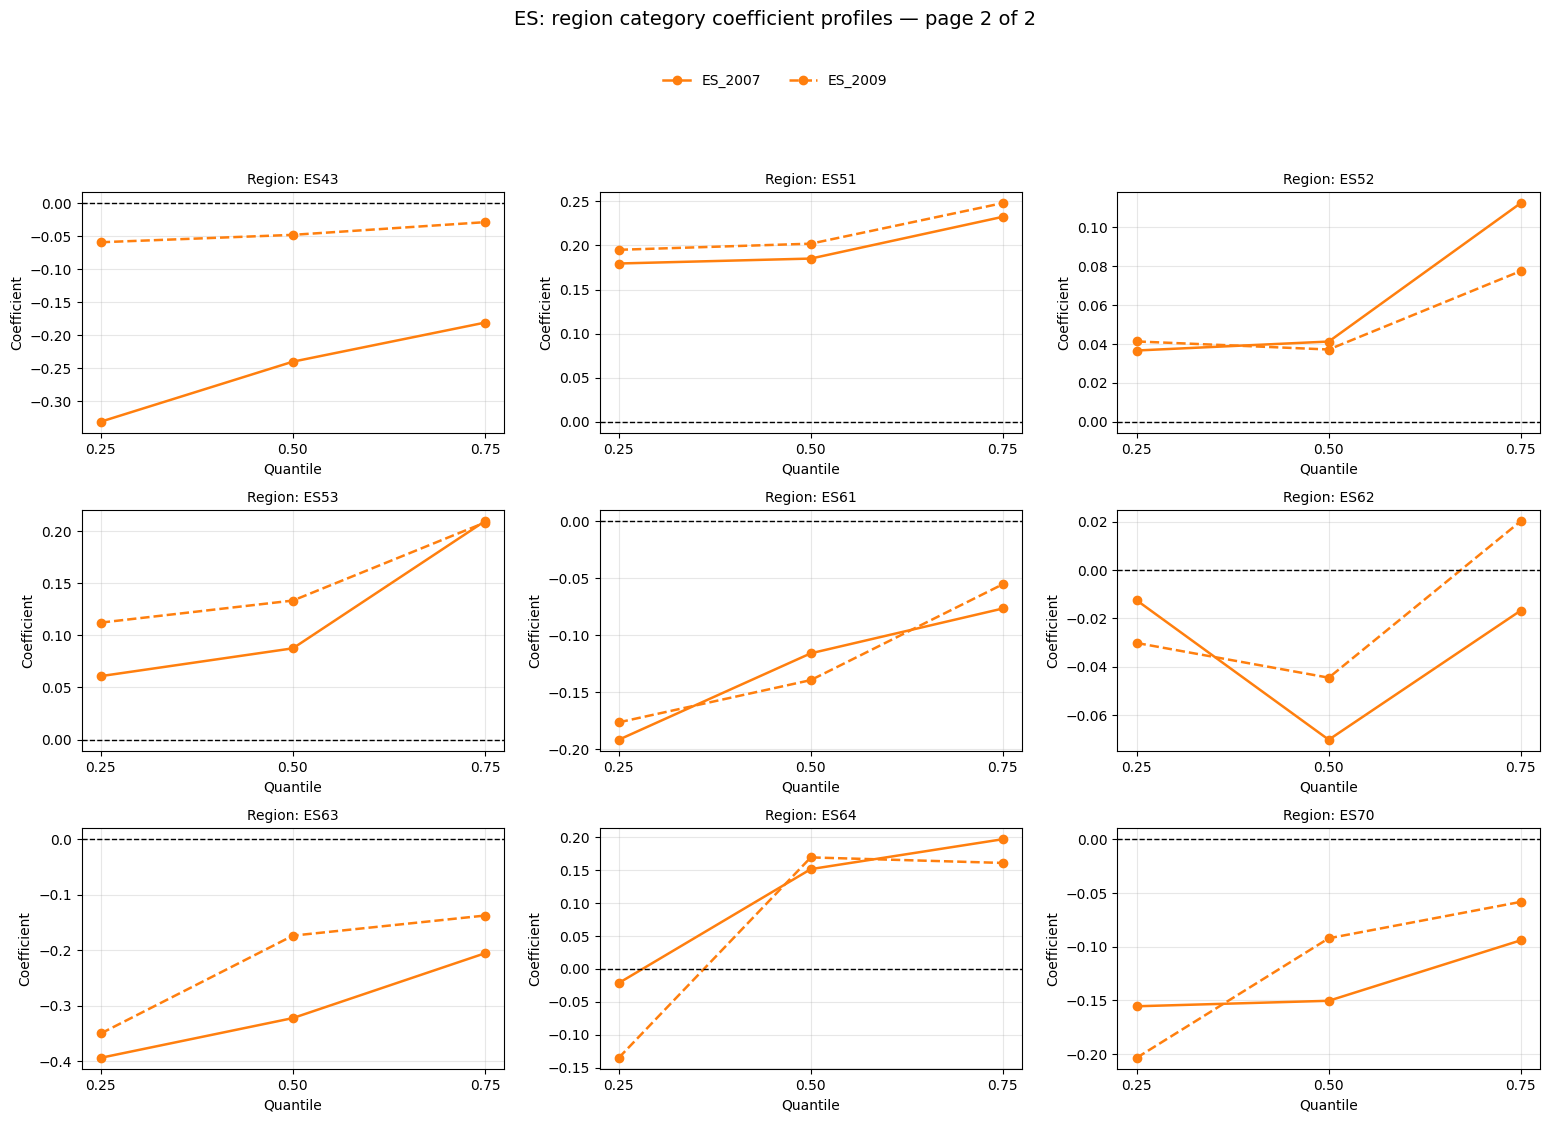

Saved: figures/all_category_profiles/ES_region_category_profiles.pdf


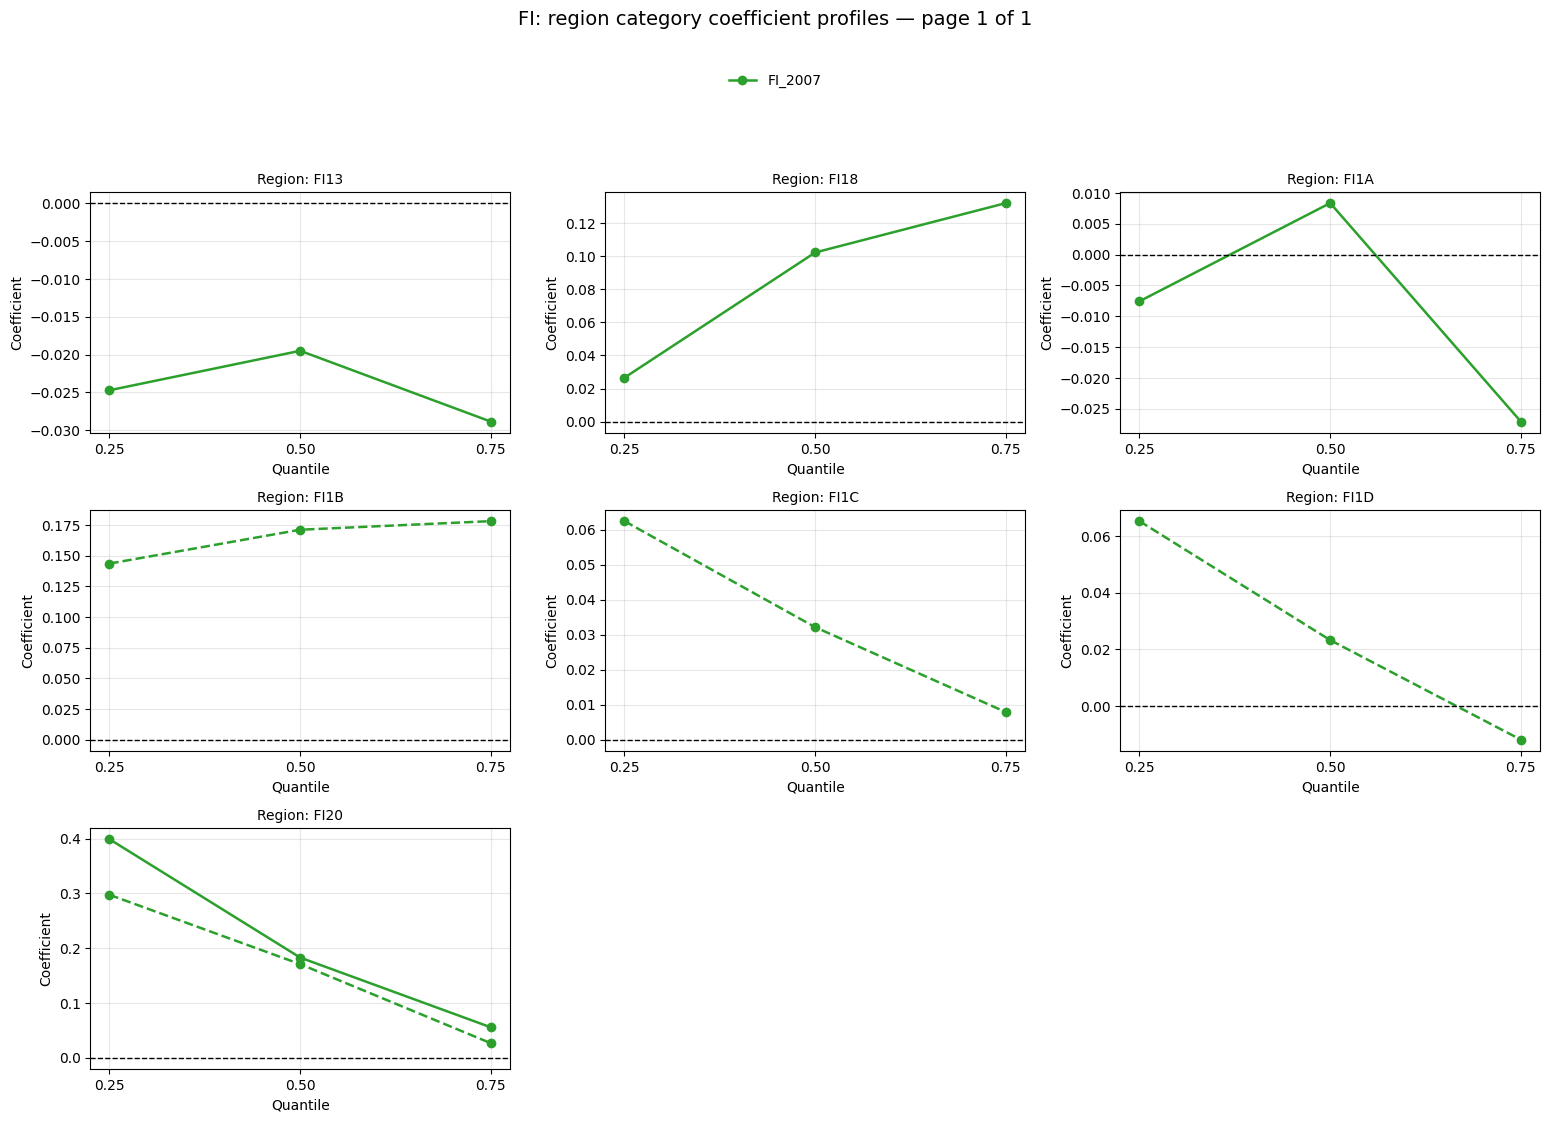

Saved: figures/all_category_profiles/FI_region_category_profiles.pdf


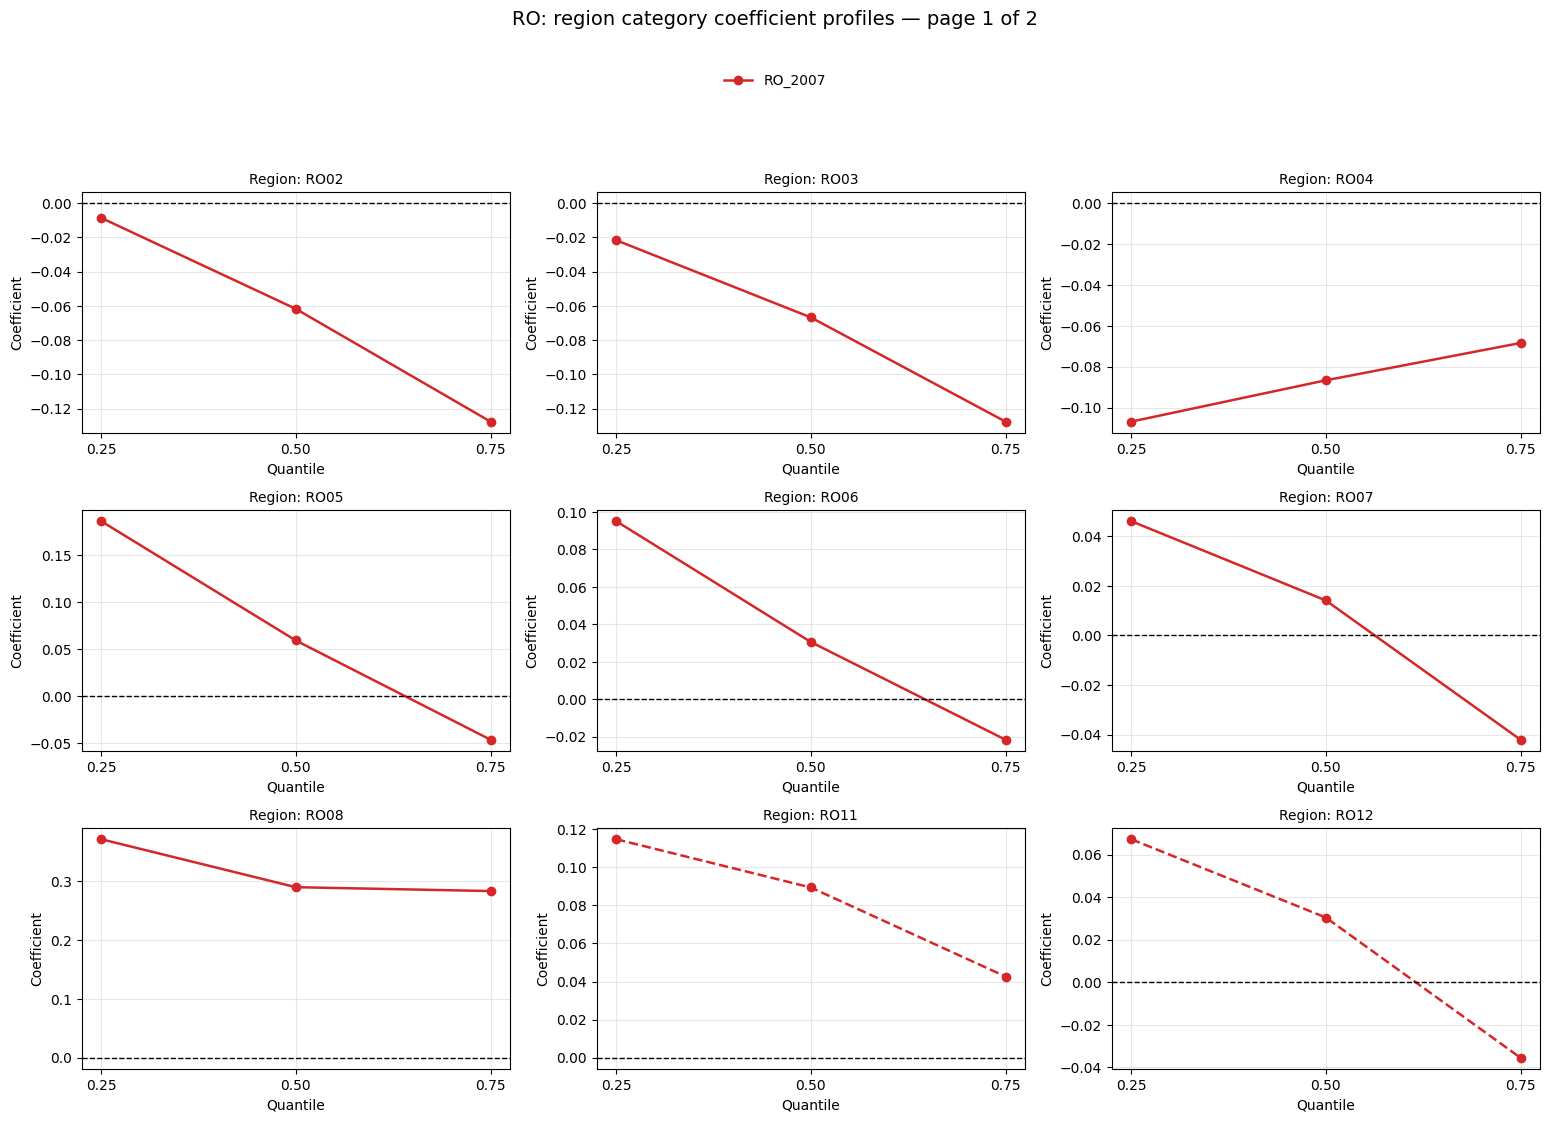

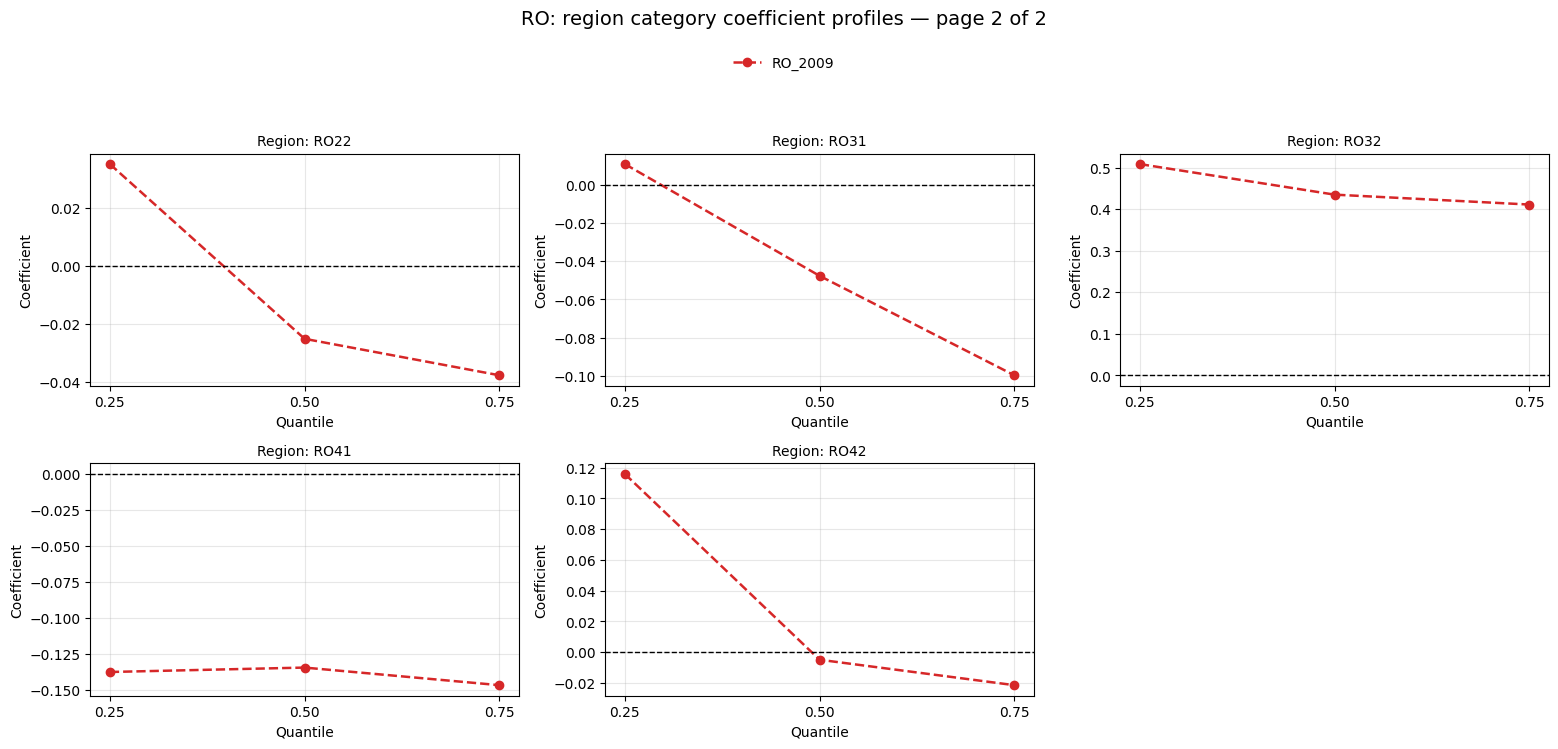

Saved: figures/all_category_profiles/RO_region_category_profiles.pdf

Done. All figures are saved in:
figures/all_category_profiles


In [24]:
# ======================================================
# Plot all category-level quantile coefficient profiles
# Extended circumstance model
# ======================================================

import os
import math
import textwrap
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages

# ------------------------------------------------------
# Check required object
# ------------------------------------------------------

if "summary_all" not in globals():
    raise ValueError("summary_all is missing. Please run the summary/pivot cell first.")

plot_dir = "figures/all_category_profiles"
os.makedirs(plot_dir, exist_ok=True)

# ------------------------------------------------------
# Basic settings
# ------------------------------------------------------

quantile_x = [0.25, 0.50, 0.75]
coef_cols = ["coef_q25", "coef_q50", "coef_q75"]

country_colors = {
    "BE": "tab:blue",
    "ES": "tab:orange",
    "FI": "tab:green",
    "RO": "tab:red"
}

year_linestyles = {
    "2007": "-",
    "2009": "--"
}

def get_country_year(dataset):
    country, year = dataset.split("_")
    return country, year

def wrap_title(text, width=38):
    return "\n".join(textwrap.wrap(str(text), width=width))

# ------------------------------------------------------
# Plotting function
# ------------------------------------------------------

def plot_variable_pages(
    variables,
    data,
    pdf_path,
    main_title,
    ncols=3,
    per_page=9,
    show_figures=True
):
    """
    Plot coefficient profiles for many variables.
    One subplot = one category/contrast.
    One line = one country-year dataset.
    Saves all pages into one PDF.
    """

    variables = [v for v in variables if v in data["Variable"].unique()]
    variables = sorted(variables)

    if len(variables) == 0:
        print(f"No variables found for: {main_title}")
        return

    with PdfPages(pdf_path) as pdf:
        for page_start in range(0, len(variables), per_page):
            page_vars = variables[page_start:page_start + per_page]

            n = len(page_vars)
            nrows = math.ceil(n / ncols)

            fig, axes = plt.subplots(
                nrows,
                ncols,
                figsize=(5.2 * ncols, 3.8 * nrows),
                squeeze=False
            )

            axes = axes.flatten()

            for i, var in enumerate(page_vars):
                ax = axes[i]
                temp = data[data["Variable"] == var].copy()

                for dataset in sorted(temp["Dataset"].unique()):
                    row = temp[temp["Dataset"] == dataset].iloc[0]
                    country, year = get_country_year(dataset)

                    ax.plot(
                        quantile_x,
                        [row["coef_q25"], row["coef_q50"], row["coef_q75"]],
                        marker="o",
                        linewidth=1.8,
                        color=country_colors.get(country, "black"),
                        linestyle=year_linestyles.get(year, "-"),
                        label=dataset
                    )

                ax.axhline(0, color="black", linestyle="--", linewidth=1)
                ax.set_title(wrap_title(var), fontsize=10)
                ax.set_xlabel("Quantile")
                ax.set_ylabel("Coefficient")
                ax.set_xticks(quantile_x)
                ax.grid(True, alpha=0.3)

            # Remove empty subplots
            for j in range(len(page_vars), len(axes)):
                fig.delaxes(axes[j])

            # Shared legend and title
            handles, labels = axes[0].get_legend_handles_labels()

            page_no = page_start // per_page + 1
            total_pages = math.ceil(len(variables) / per_page)

            fig.suptitle(
                f"{main_title} — page {page_no} of {total_pages}",
                y=0.98,
                fontsize=14
            )

            fig.legend(
                handles,
                labels,
                loc="upper center",
                bbox_to_anchor=(0.5, 0.935),
                ncol=4,
                frameon=False
            )

            # Leave enough space for title and legend
            plt.tight_layout(rect=[0, 0, 1, 0.88])

            pdf.savefig(fig, bbox_inches="tight")

            if show_figures:
                plt.show()
            else:
                plt.close(fig)

    print(f"Saved: {pdf_path}")

# ------------------------------------------------------
# Prepare variables
# ------------------------------------------------------

all_vars = sorted([
    v for v in summary_all["Variable"].unique()
    if v != "const"
])

non_region_vars = [
    v for v in all_vars
    if not str(v).startswith("Region:")
]

region_vars = [
    v for v in all_vars
    if str(v).startswith("Region:")
]

# ------------------------------------------------------
# 1. Plot all non-region categories together
# ------------------------------------------------------

plot_variable_pages(
    variables=non_region_vars,
    data=summary_all,
    pdf_path=os.path.join(plot_dir, "all_non_region_category_profiles.pdf"),
    main_title="All non-region category coefficient profiles",
    ncols=3,
    per_page=9,
    show_figures=True
)

# ------------------------------------------------------
# 2. Plot region categories separately by country
#    This is clearer because region categories are country-specific.
# ------------------------------------------------------

for country in ["BE", "ES", "FI", "RO"]:
    country_region_vars = []

    for var in region_vars:
        temp = summary_all[summary_all["Variable"] == var]
        datasets_for_var = temp["Dataset"].astype(str).unique()

        if any(ds.startswith(country + "_") for ds in datasets_for_var):
            country_region_vars.append(var)

    country_data = summary_all[
        summary_all["Dataset"].astype(str).str.startswith(country + "_")
    ].copy()

    plot_variable_pages(
        variables=country_region_vars,
        data=country_data,
        pdf_path=os.path.join(plot_dir, f"{country}_region_category_profiles.pdf"),
        main_title=f"{country}: region category coefficient profiles",
        ncols=3,
        per_page=9,
        show_figures=True
    )

print("\nDone. All figures are saved in:")
print(plot_dir)

for appendix

In [25]:
# ======================================================
# Generate Quantile Regression Appendix Outputs
# Tables in .tex + coefficient profile figures in .pdf
# ======================================================

import os
import math
import textwrap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages

# ------------------------------------------------------
# 0. Output folder
# ------------------------------------------------------

appendix_dir = "appendix_quantile_outputs"
os.makedirs(appendix_dir, exist_ok=True)

# ------------------------------------------------------
# 1. Basic checks
# ------------------------------------------------------

if "summary_all" not in globals():
    raise ValueError(
        "summary_all is missing. Please run the quantile-regression summary cell first."
    )

required_cols = {"Dataset", "Variable", "coef_q25", "coef_q50", "coef_q75"}
missing_cols = required_cols - set(summary_all.columns)

if missing_cols:
    raise ValueError(f"summary_all is missing these required columns: {missing_cols}")

# ------------------------------------------------------
# 2. Helper functions
# ------------------------------------------------------

def latex_escape(text):
    """
    Escape common LaTeX special characters in text columns.
    """
    if pd.isna(text):
        return ""
    text = str(text)
    replacements = {
        "\\": r"\textbackslash{}",
        "&": r"\&",
        "%": r"\%",
        "$": r"\$",
        "#": r"\#",
        "_": r"\_",
        "{": r"\{",
        "}": r"\}",
        "~": r"\textasciitilde{}",
        "^": r"\textasciicircum{}",
    }
    for old, new in replacements.items():
        text = text.replace(old, new)
    return text


def significance_stars(p):
    """
    Convert p-value into significance stars.
    """
    if pd.isna(p):
        return ""
    if p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    else:
        return ""


def format_coef(row, coef_col, p_col=None):
    """
    Format coefficient with optional significance stars.
    """
    coef = row.get(coef_col, np.nan)
    if pd.isna(coef):
        return ""

    stars = ""
    if p_col is not None and p_col in row.index:
        stars = significance_stars(row[p_col])

    return f"{coef:.3f}{stars}"


def export_longtable_tex(df, path, caption, label):
    """
    Export a clean longtable to a .tex file.
    The file can be inserted with \\input{...}.
    """

    lines = []

    lines.append(r"\begin{landscape}")
    lines.append(r"\scriptsize")
    lines.append(r"\setlength{\tabcolsep}{4pt}")
    lines.append(r"\renewcommand{\arraystretch}{1.1}")
    lines.append(r"\begin{longtable}{llccc}")
    lines.append(rf"\caption{{{caption}}}\label{{{label}}}\\")
    lines.append(r"\toprule")
    lines.append(r"Dataset & Variable & q25 & q50 & q75 \\")
    lines.append(r"\midrule")
    lines.append(r"\endfirsthead")

    lines.append(r"\caption[]{%s (continued)}\\" % caption)
    lines.append(r"\toprule")
    lines.append(r"Dataset & Variable & q25 & q50 & q75 \\")
    lines.append(r"\midrule")
    lines.append(r"\endhead")

    lines.append(r"\midrule")
    lines.append(r"\multicolumn{5}{r}{Continued on next page} \\")
    lines.append(r"\endfoot")

    lines.append(r"\bottomrule")
    lines.append(r"\endlastfoot")

    for _, row in df.iterrows():
        dataset = latex_escape(row["Dataset"])
        variable = latex_escape(row["Variable"])
        q25 = latex_escape(row["q25"])
        q50 = latex_escape(row["q50"])
        q75 = latex_escape(row["q75"])

        lines.append(f"{dataset} & {variable} & {q25} & {q50} & {q75} \\\\")

    lines.append(r"\end{longtable}")
    lines.append(r"\normalsize")
    lines.append(r"\end{landscape}")

    with open(path, "w", encoding="utf-8") as f:
        f.write("\n".join(lines))

    print(f"Saved table: {path}")


def export_dataframe_tex(df, path, caption, label):
    """
    Export a general dataframe as a longtable.
    Used for small-category tables.
    """

    df = df.copy()

    # Convert all values to LaTeX-safe strings
    for col in df.columns:
        df[col] = df[col].apply(latex_escape)

    latex = df.to_latex(
        index=False,
        longtable=True,
        escape=False,
        caption=caption,
        label=label
    )

    latex = (
        r"\begin{landscape}" + "\n"
        r"\scriptsize" + "\n"
        + latex + "\n"
        r"\normalsize" + "\n"
        r"\end{landscape}"
    )

    with open(path, "w", encoding="utf-8") as f:
        f.write(latex)

    print(f"Saved table: {path}")


# ------------------------------------------------------
# 3. Prepare coefficient tables
# ------------------------------------------------------

coef_table = summary_all.copy()

coef_table = coef_table[coef_table["Variable"].astype(str) != "const"].copy()

# Optional p-value columns
p25_col = "p_q25" if "p_q25" in coef_table.columns else None
p50_col = "p_q50" if "p_q50" in coef_table.columns else None
p75_col = "p_q75" if "p_q75" in coef_table.columns else None

coef_table["q25"] = coef_table.apply(lambda r: format_coef(r, "coef_q25", p25_col), axis=1)
coef_table["q50"] = coef_table.apply(lambda r: format_coef(r, "coef_q50", p50_col), axis=1)
coef_table["q75"] = coef_table.apply(lambda r: format_coef(r, "coef_q75", p75_col), axis=1)

coef_table = coef_table[["Dataset", "Variable", "q25", "q50", "q75"]].copy()

non_region_table = coef_table[
    ~coef_table["Variable"].astype(str).str.startswith("Region:")
].copy()

region_table = coef_table[
    coef_table["Variable"].astype(str).str.startswith("Region:")
].copy()

non_region_table = non_region_table.sort_values(["Variable", "Dataset"])
region_table = region_table.sort_values(["Dataset", "Variable"])

# ------------------------------------------------------
# 4. Export coefficient tables as .tex
# ------------------------------------------------------

non_region_tex = os.path.join(
    appendix_dir,
    "appendix_quantile_non_region_coefficients.tex"
)

region_tex = os.path.join(
    appendix_dir,
    "appendix_quantile_region_coefficients.tex"
)

export_longtable_tex(
    df=non_region_table,
    path=non_region_tex,
    caption="Full non-regional quantile regression coefficients",
    label="tab:appendix-quantile-non-region-coefficients"
)

export_longtable_tex(
    df=region_table,
    path=region_tex,
    caption="Full regional quantile regression coefficients",
    label="tab:appendix-quantile-region-coefficients"
)

# ------------------------------------------------------
# 5. Export small-category table if available
# ------------------------------------------------------

small_categories_tex = os.path.join(
    appendix_dir,
    "appendix_quantile_small_categories.tex"
)

small_table_created = False

if "small_categories" in globals():
    small_categories_export = small_categories.copy()
    export_dataframe_tex(
        df=small_categories_export,
        path=small_categories_tex,
        caption="Small categories in the extended circumstance quantile regression samples",
        label="tab:appendix-quantile-small-categories"
    )
    small_table_created = True

else:
    print(
        "small_categories object not found. "
        "No small-category appendix table was created."
    )

# ------------------------------------------------------
# 6. Full coefficient profile figures
# ------------------------------------------------------

quantile_x = [0.25, 0.50, 0.75]

country_colors = {
    "BE": "tab:blue",
    "ES": "tab:orange",
    "FI": "tab:green",
    "RO": "tab:red"
}

year_linestyles = {
    "2007": "-",
    "2009": "--"
}


def get_country_year(dataset):
    parts = str(dataset).split("_")
    if len(parts) >= 2:
        return parts[0], parts[1]
    return str(dataset), ""


def wrap_title(text, width=38):
    return "\n".join(textwrap.wrap(str(text), width=width))


def plot_variable_pages(
    variables,
    data,
    pdf_path,
    main_title,
    ncols=3,
    per_page=9
):
    """
    Plot coefficient profiles for many variables.
    One subplot = one category.
    One line = one country-year dataset.
    The output is a multi-page PDF.
    """

    variables = [v for v in variables if v in data["Variable"].unique()]
    variables = sorted(variables)

    if len(variables) == 0:
        print(f"No variables found for: {main_title}")
        return

    with PdfPages(pdf_path) as pdf:
        for page_start in range(0, len(variables), per_page):
            page_vars = variables[page_start:page_start + per_page]

            n = len(page_vars)
            nrows = math.ceil(n / ncols)

            fig, axes = plt.subplots(
                nrows,
                ncols,
                figsize=(5.2 * ncols, 3.8 * nrows),
                squeeze=False
            )

            axes = axes.flatten()

            for i, var in enumerate(page_vars):
                ax = axes[i]
                temp = data[data["Variable"] == var].copy()

                for dataset in sorted(temp["Dataset"].unique()):
                    row = temp[temp["Dataset"] == dataset].iloc[0]
                    country, year = get_country_year(dataset)

                    ax.plot(
                        quantile_x,
                        [row["coef_q25"], row["coef_q50"], row["coef_q75"]],
                        marker="o",
                        linewidth=1.8,
                        color=country_colors.get(country, "black"),
                        linestyle=year_linestyles.get(year, "-"),
                        label=dataset
                    )

                ax.axhline(0, color="black", linestyle="--", linewidth=1)
                ax.set_title(wrap_title(var), fontsize=10)
                ax.set_xlabel("Quantile")
                ax.set_ylabel("Coefficient")
                ax.set_xticks(quantile_x)
                ax.grid(True, alpha=0.3)

            # Remove empty subplots
            for j in range(len(page_vars), len(axes)):
                fig.delaxes(axes[j])

            handles, labels = axes[0].get_legend_handles_labels()

            page_no = page_start // per_page + 1
            total_pages = math.ceil(len(variables) / per_page)

            fig.suptitle(
                f"{main_title} — page {page_no} of {total_pages}",
                y=0.98,
                fontsize=14
            )

            fig.legend(
                handles,
                labels,
                loc="upper center",
                bbox_to_anchor=(0.5, 0.935),
                ncol=4,
                frameon=False
            )

            plt.tight_layout(rect=[0, 0, 1, 0.88])
            pdf.savefig(fig, bbox_inches="tight")
            plt.close(fig)

    print(f"Saved figure PDF: {pdf_path}")


all_vars = sorted([
    v for v in summary_all["Variable"].unique()
    if str(v) != "const"
])

non_region_vars = [
    v for v in all_vars
    if not str(v).startswith("Region:")
]

region_vars = [
    v for v in all_vars
    if str(v).startswith("Region:")
]

all_non_region_pdf = os.path.join(
    appendix_dir,
    "all_non_region_category_profiles.pdf"
)

plot_variable_pages(
    variables=non_region_vars,
    data=summary_all,
    pdf_path=all_non_region_pdf,
    main_title="All non-regional quantile coefficient profiles",
    ncols=3,
    per_page=9
)

region_pdf_paths = {}

for country in ["BE", "ES", "FI", "RO"]:

    country_data = summary_all[
        summary_all["Dataset"].astype(str).str.startswith(country + "_")
    ].copy()

    country_region_vars = [
        v for v in region_vars
        if v in country_data["Variable"].unique()
    ]

    country_pdf = os.path.join(
        appendix_dir,
        f"{country}_region_category_profiles.pdf"
    )

    plot_variable_pages(
        variables=country_region_vars,
        data=country_data,
        pdf_path=country_pdf,
        main_title=f"{country}: regional quantile coefficient profiles",
        ncols=3,
        per_page=9
    )

    region_pdf_paths[country] = country_pdf

# ------------------------------------------------------
# 7. Create LaTeX include block for thesis appendix
# ------------------------------------------------------

include_block_path = os.path.join(
    appendix_dir,
    "appendix_quantile_include_block.tex"
)

include_lines = []

include_lines.append(r"% ------------------------------------------------------")
include_lines.append(r"% Additional Quantile Regression Results")
include_lines.append(r"% Add \usepackage{pdfpages} in the preamble before using \includepdf")
include_lines.append(r"% ------------------------------------------------------")
include_lines.append("")
include_lines.append(r"\clearpage")
include_lines.append(r"\section{Additional Quantile Regression Results}")
include_lines.append("")
include_lines.append(r"\subsection{Complete coefficient tables}")
include_lines.append(r"\input{appendix_quantile_outputs/appendix_quantile_non_region_coefficients.tex}")
include_lines.append("")
include_lines.append(r"\clearpage")
include_lines.append(r"\input{appendix_quantile_outputs/appendix_quantile_region_coefficients.tex}")
include_lines.append("")

if small_table_created:
    include_lines.append(r"\clearpage")
    include_lines.append(r"\subsection{Small-category cautions}")
    include_lines.append(r"\input{appendix_quantile_outputs/appendix_quantile_small_categories.tex}")
    include_lines.append("")

include_lines.append(r"\clearpage")
include_lines.append(r"\subsection{Full coefficient profile figures}")
include_lines.append("")
include_lines.append(r"\includepdf[pages=-,scale=0.95,pagecommand={\thispagestyle{plain}}]{appendix_quantile_outputs/all_non_region_category_profiles.pdf}")
include_lines.append("")

for country in ["BE", "ES", "FI", "RO"]:
    include_lines.append(r"\clearpage")
    include_lines.append(
        rf"\includepdf[pages=-,scale=0.95,pagecommand={{\thispagestyle{{plain}}}}]{{appendix_quantile_outputs/{country}_region_category_profiles.pdf}}"
    )
    include_lines.append("")

with open(include_block_path, "w", encoding="utf-8") as f:
    f.write("\n".join(include_lines))

print(f"Saved LaTeX include block: {include_block_path}")

print("\nDone. Appendix outputs saved in:")
print(appendix_dir)

print("\nIn your thesis preamble, add this if not already included:")
print(r"\usepackage{pdfpages}")

print("\nIn your appendix, insert:")
print(r"\input{appendix_quantile_outputs/appendix_quantile_include_block.tex}")

Saved table: appendix_quantile_outputs/appendix_quantile_non_region_coefficients.tex
Saved table: appendix_quantile_outputs/appendix_quantile_region_coefficients.tex
Saved table: appendix_quantile_outputs/appendix_quantile_small_categories.tex
Saved figure PDF: appendix_quantile_outputs/all_non_region_category_profiles.pdf
Saved figure PDF: appendix_quantile_outputs/BE_region_category_profiles.pdf
Saved figure PDF: appendix_quantile_outputs/ES_region_category_profiles.pdf
Saved figure PDF: appendix_quantile_outputs/FI_region_category_profiles.pdf
Saved figure PDF: appendix_quantile_outputs/RO_region_category_profiles.pdf
Saved LaTeX include block: appendix_quantile_outputs/appendix_quantile_include_block.tex

Done. Appendix outputs saved in:
appendix_quantile_outputs

In your thesis preamble, add this if not already included:
\usepackage{pdfpages}

In your appendix, insert:
\input{appendix_quantile_outputs/appendix_quantile_include_block.tex}
